# COMP 333 Final Project — End-to-End Pipeline
## Dataset: NYC TLC Yellow Taxi (2024–2025)

**Course:** COMP 333 &nbsp;|&nbsp; **Submitted:** April 2026 &nbsp;|&nbsp; **Team:** Arad Hajari · Noah Burns · Paolo Ciccarelli · Sang Ho Lee

---

## Executive Summary

### Problem Statement
New York City's yellow taxi market generates tens of millions of trips per year. Understanding what drives fare levels — and discovering hidden structure in trip patterns — has direct value for pricing audits, passenger demand forecasting, and resource allocation. This project asks two research questions:

1. **Supervised:** Can trip attributes accurately classify a fare into a *low* (< \$15), *mid* (\$15–\$40), or *high* (≥ \$40) tier?
2. **Unsupervised:** Do natural, interpretable groupings emerge from trip-structure features alone?

### Dataset
We downloaded **24 months** of NYC TLC Yellow Taxi Parquet records (January 2024 – December 2025) directly from the official TLC CDN. The raw data exceeds **1 GB** and spans approximately **83 million trips** after concatenation. Each record includes pickup/drop-off timestamps, GPS location zone IDs, trip distance, passenger count, payment type, metered fare, and tip amount.

### Methods Summary

| Phase | Stage | Technique |
|-------|-------|-----------|
| 1 | Data Retrieval | Programmatic Parquet downloads; SHA-256 checksums; retrieval log |
| 1 | Data Cleaning | Deduplication, plausibility filters (speed, distance, fare, duration), median imputation |
| 1 | EDA | Descriptive statistics, distribution plots, correlation heatmap, baseline KMeans preview |
| 1 | Baseline Model | Simple linear regression: `fare_amount ~ trip_distance` |
| 2 | Feature Engineering | Time features, log-distance transform, domain flags (airport, overnight) |
| 2 | Advanced Supervised | GridSearchCV over Random Forest, MLP, XGBoost (3-fold stratified CV) |
| 2 | Feature Selection | Filter (Mutual Info), Wrapper (Forward SFS), Embedded (RF importance + L1) |
| 2 | Unsupervised | PCA → KMeans k-selection → stability checks → method comparison (KMeans / Agglomerative / GMM) |
| 2 | Interpretation | XGBoost feature importances + Partial Dependence Plots |

### Key Findings

**Baseline model** (`fare_amount = 7.10 + 3.67 × trip_distance`) achieves R² ≈ 0.85, confirming the strong linear relationship between distance and fare. However, systematic residual banding and heteroscedasticity reveal that distance alone is insufficient — time-based surcharges, tolls, and airport premiums are missed.

**Advanced supervised learning** confirms XGBoost as the best classifier, outperforming both Random Forest and MLP on macro F1 and ROC-AUC across all three fare tiers. `trip_distance`, `trip_duration_min`, and `log_distance` are the dominant predictors.  Feature selection shows the consensus subset retains near-full performance with fewer features.

**Unsupervised learning** discovers three to four compact, stable trip clusters (confirmed by high ARI across seeds and subsamples). The clusters correspond to interpretable NYC trip archetypes: short/quick city trips; medium-distance standard trips; and long/airport or cross-borough trips. These clusters align closely with the `fare_tier` labels, validating that unsupervised structure reinforces the supervised task.

---

## Table of Contents

| # | Section | Key Outputs |
|---|---------|-------------|
| 1 | [Configuration & Imports](#configuration--imports) | Constants, paths, libraries |
| 2 | [Data Retrieval](#data-retrieval) | Parquet downloads, retrieval log, ≥1 GB check |
| 3 | [Data Cleaning](#data-cleaning) | `phase1_cleaned.parquet`, cleaning audit |
| 4 | [Load Cleaned Data](#load-cleaned-data) | Row count, size verification |
| 5 | [Exploratory Data Analysis](#exploratory-data-analysis-eda) | Descriptive stats, histograms, scatter, heatmap |
| 6 | [Baseline Model](#baseline-model--simple-linear-regression) | Linear regression metrics, residual plot |
| 7 | [Feature Engineering & Target](#feature-engineering--target-definition) | Engineered columns, `fare_tier` distribution |
| 8 | [Sampling & Train/Test Split](#sampling--traintest-split) | Stratified samples for all downstream stages |
| 9 | [Advanced Supervised Learning](#advanced-supervised-learning) | ROC curves, confusion matrices, model comparison |
| 10 | [Feature Selection](#feature-selection-comparison) | Filter / Wrapper / Embedded comparison |
| 11 | [Unsupervised Learning](#unsupervised-learning) | PCA, KMeans, clustering method comparison |
| 12 | [Interpretation](#interpretation) | Feature importances, Partial Dependence Plots |
| — | [Ethical Considerations](#ethical-considerations) | Ethical Considerations |
| — | [Division of Labour](#division-of-labour) | Contribution table |
| — | [References](#references) | Citations |

---


<a id="configuration--imports"></a>
## 1. Configuration & Imports

> **To reproduce on new data:** update `START_MONTH`, `END_MONTH`, and/or the cleaning filter constants below. All other settings are derived automatically.

In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION  —  Edit these values to adapt the pipeline to new data
# ═══════════════════════════════════════════════════════════════════════════════
import csv, hashlib, json, time, warnings
from datetime import UTC, datetime
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import skew, kurtosis

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import (
    SelectKBest, SequentialFeatureSelector, mutual_info_classif,
)
from sklearn.inspection import PartialDependenceDisplay
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, adjusted_rand_score,
    calinski_harabasz_score, classification_report, confusion_matrix,
    davies_bouldin_score, f1_score, mean_absolute_error,
    mean_squared_error, precision_score, r2_score, recall_score,
    roc_auc_score, roc_curve, silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize

import requests

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

# ── Paths ──────────────────────────────────────────────────────────────────────
# Auto-detects project root whether the notebook is run from repo root or notebooks/
_root = (
    Path(".").resolve()
    if (Path(".").resolve() / "data" / "raw").exists()
    else Path("..").resolve()
)
RAW_DIR       = _root / "data" / "raw"
PROCESSED_DIR = _root / "data" / "processed"
CLEANED_PATH  = PROCESSED_DIR / "phase1_cleaned.parquet"
AUDIT_PATH    = PROCESSED_DIR / "cleaning_audit.json"
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# ── Download settings ──────────────────────────────────────────────────────────
BASE_URL      = "https://d37ci6vzurychx.cloudfront.net/trip-data"
START_MONTH   = "2024-01"   # First month to download (YYYY-MM)
END_MONTH     = "2025-12"   # Last month to download  (YYYY-MM)
SKIP_EXISTING = True        # Set False to force re-download of all files

# ── Cleaning thresholds ────────────────────────────────────────────────────────
MAX_DURATION_MIN = 240       # Drop trips longer than 4 hours
MAX_SPEED_MPH    = 80        # Drop trips with average speed > 80 mph
MAX_DISTANCE_MI  = 200       # Drop trips longer than 200 miles
MAX_FARE         = 500       # Drop fares above $500
MAX_TIP          = 200       # Drop tips above $200

# ── Modelling ──────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
N_SUP        = 500_000       # Rows for supervised learning
N_WRAP       = 100_000       # Rows for wrapper feature-selection
N_UNSUP      = 100_000       # Rows for unsupervised learning
FARE_BINS    = [0, 15, 40, float("inf")]
FARE_LABELS  = ["low", "mid", "high"]

# ── Unsupervised evaluation subsets ───────────────────────────────────────────
MAX_EVAL     = 8_000         # Max rows for clustering method comparison (G.9)
MAX_SIL      = 5_000         # Max rows for silhouette scoring in G.9

# ── Column definitions ─────────────────────────────────────────────────────────
REQUIRED_COLS = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "trip_distance", "fare_amount", "tip_amount",
    "passenger_count", "payment_type",
    "PULocationID", "DOLocationID",
]
BASE_FEATURES = [
    "trip_distance", "trip_duration_min", "speed_mph",
    "passenger_count", "payment_type",
]
ENG_FEATURES = BASE_FEATURES + [
    "pickup_hour", "pickup_dayofweek", "is_weekend",
    "log_distance", "is_overnight", "is_airport_trip",
]
UNSUP_FEATURES = [
    "trip_distance", "trip_duration_min", "speed_mph",
    "passenger_count", "pickup_hour", "pickup_dayofweek",
]
AIRPORT_IDS = {132, 138, 1}
TARGET = "fare_tier"

print("✓ Configuration loaded.")
print(f"  Project root : {_root}")
print(f"  Raw data dir : {RAW_DIR}")
print(f"  Processed dir: {PROCESSED_DIR}")


✓ Configuration loaded.
  Project root : C:\Users\prowl
  Raw data dir : C:\Users\prowl\data\raw
  Processed dir: C:\Users\prowl\data\processed


<a id="data-retrieval"></a>
## 2. Data Retrieval

Downloads NYC TLC Yellow Taxi Parquet files from the official source into `data/raw/`.  
Each download is logged (URL, timestamp, size, SHA-256 checksum, status).  
Files already on disk are skipped when `SKIP_EXISTING = True`.


In [2]:
class DataRetriever:
    """
    Downloads NYC TLC monthly Parquet files and maintains a retrieval log.

    Parameters
    ----------
    base_url      : CDN prefix for the TLC Parquet files.
    raw_dir       : Destination directory for downloaded files.
    log_path      : Path to the CSV retrieval log (auto-set to raw_dir/retrieval_log.csv).
    skip_existing : If True, skip files that are already on disk.
    """

    def __init__(self, base_url: str, raw_dir: Path,
                 log_path: Path = None, skip_existing: bool = True):
        self.base_url      = base_url
        self.raw_dir       = Path(raw_dir)
        self.log_path      = log_path or self.raw_dir / "retrieval_log.csv"
        self.skip_existing = skip_existing

    # ── Private helpers ────────────────────────────────────────────────────────
    @staticmethod
    def _month_range(start: str, end: str):
        """Yield 'YYYY-MM' strings from *start* through *end* (inclusive)."""
        dt     = datetime.strptime(start, "%Y-%m")
        end_dt = datetime.strptime(end,   "%Y-%m")
        while dt <= end_dt:
            yield dt.strftime("%Y-%m")
            month = dt.month % 12 + 1
            year  = dt.year + (1 if dt.month == 12 else 0)
            dt    = dt.replace(year=year, month=month)

    @staticmethod
    def _stream_download(url: str, dest: Path,
                         retries: int = 3, timeout: int = 60):
        """
        Stream-download *url* to *dest* in 1 MB chunks.
        Computes SHA-256 on-the-fly.
        Retries with exponential back-off on transient errors.
        Returns (bytes_written, sha256_hex).
        """
        for attempt in range(1, retries + 1):
            try:
                with requests.get(url, stream=True, timeout=timeout) as r:
                    r.raise_for_status()
                    hasher, total = hashlib.sha256(), 0
                    with dest.open("wb") as f:
                        for chunk in r.iter_content(chunk_size=1 << 20):
                            if chunk:
                                f.write(chunk)
                                hasher.update(chunk)
                                total += len(chunk)
                    return total, hasher.hexdigest()
            except Exception as exc:
                if attempt == retries:
                    raise RuntimeError(
                        f"Download failed after {retries} attempts: {exc}"
                    ) from exc
                time.sleep(2 ** attempt)

    def _append_log(self, row: dict) -> None:
        """Append one record to retrieval_log.csv (writes header on first call)."""
        headers      = ["url", "filename", "downloaded_at_utc",
                        "bytes", "sha256", "status", "note"]
        needs_header = not self.log_path.exists()
        with self.log_path.open("a", newline="", encoding="utf-8") as f:
            w = csv.DictWriter(f, fieldnames=headers)
            if needs_header:
                w.writeheader()
            w.writerow(row)

    # ── Public API ─────────────────────────────────────────────────────────────
    def run(self, start_month: str, end_month: str) -> float:
        """
        Download all monthly files in [start_month, end_month].
        Returns the total on-disk size of all Parquet files in GB.
        Also writes a human-readable size_summary.txt.
        """
        for month in self._month_range(start_month, end_month):
            filename = f"yellow_tripdata_{month}.parquet"
            dest     = self.raw_dir / filename
            url      = f"{self.base_url}/{filename}"
            now_utc  = (datetime.now(UTC)
                        .isoformat(timespec="seconds")
                        .replace("+00:00", "Z"))

            if self.skip_existing and dest.exists():
                self._append_log({
                    "url": url, "filename": filename,
                    "downloaded_at_utc": now_utc,
                    "bytes": dest.stat().st_size,
                    "sha256": "existing_file_not_rehashed",
                    "status": "skipped", "note": "File exists.",
                })
                print(f"  [skip]  {filename}")
                continue

            try:
                nb, sha = self._stream_download(url, dest)
                self._append_log({
                    "url": url, "filename": filename,
                    "downloaded_at_utc": now_utc,
                    "bytes": nb, "sha256": sha,
                    "status": "downloaded", "note": "OK",
                })
                print(f"  [ok]    {filename}  ({nb / 1e6:.1f} MB)")
            except Exception as exc:
                dest.unlink(missing_ok=True)
                self._append_log({
                    "url": url, "filename": filename,
                    "downloaded_at_utc": now_utc,
                    "bytes": 0, "sha256": "",
                    "status": "failed", "note": str(exc),
                })
                print(f"  [fail]  {filename}: {exc}")

        total_gb = (
            sum(p.stat().st_size for p in self.raw_dir.glob("*.parquet"))
            / (1024 ** 3)
        )
        meets = "YES" if total_gb >= 1.0 else "NO"
        summary = (f"Total parquet size (GB): {total_gb:.3f}\n"
                   f"Meets >=1GB requirement: {meets}\n")
        (self.raw_dir / "size_summary.txt").write_text(summary, encoding="utf-8")
        print(f"\nTotal parquet size: {total_gb:.3f} GB  |  Meets ≥1 GB: {meets}")
        return total_gb


In [3]:
retriever = DataRetriever(
    base_url=BASE_URL,
    raw_dir=RAW_DIR,
    skip_existing=SKIP_EXISTING,
)
total_gb = retriever.run(START_MONTH, END_MONTH)


  [skip]  yellow_tripdata_2024-01.parquet
  [skip]  yellow_tripdata_2024-02.parquet
  [skip]  yellow_tripdata_2024-03.parquet
  [skip]  yellow_tripdata_2024-04.parquet
  [skip]  yellow_tripdata_2024-05.parquet
  [skip]  yellow_tripdata_2024-06.parquet
  [skip]  yellow_tripdata_2024-07.parquet
  [skip]  yellow_tripdata_2024-08.parquet
  [skip]  yellow_tripdata_2024-09.parquet
  [skip]  yellow_tripdata_2024-10.parquet
  [skip]  yellow_tripdata_2024-11.parquet
  [skip]  yellow_tripdata_2024-12.parquet
  [skip]  yellow_tripdata_2025-01.parquet
  [skip]  yellow_tripdata_2025-02.parquet
  [skip]  yellow_tripdata_2025-03.parquet
  [skip]  yellow_tripdata_2025-04.parquet
  [skip]  yellow_tripdata_2025-05.parquet
  [skip]  yellow_tripdata_2025-06.parquet
  [skip]  yellow_tripdata_2025-07.parquet
  [skip]  yellow_tripdata_2025-08.parquet
  [skip]  yellow_tripdata_2025-09.parquet
  [skip]  yellow_tripdata_2025-10.parquet
  [skip]  yellow_tripdata_2025-11.parquet
  [skip]  yellow_tripdata_2025-12.

<a id="load-cleaned-data"></a>
## 3. Data Cleaning

Applies the full reproducible cleaning pipeline:

1. Concatenate all raw monthly Parquet files
2. Remove duplicate rows
3. Parse timestamps; compute `trip_duration_min`
4. Impute `passenger_count` → 1 and `payment_type` → mode
5. Drop rows missing critical columns (pickup, dropoff, distance, fare)
6. Filter implausible trips (negative values, duration > 4 h)
7. Drop physically impossible trips (speed > 80 mph, distance > 200 mi, fare > $500, tip > $200)
8. Compute `speed_mph`
9. Write `phase1_cleaned.parquet` and `cleaning_audit.json`


In [4]:
def clean_raw_data(
    raw_dir: Path,
    required_cols: list,
    cleaned_path: Path,
    audit_path: Path,
    max_duration_min: float = MAX_DURATION_MIN,
    max_speed_mph:    float = MAX_SPEED_MPH,
    max_distance_mi:  float = MAX_DISTANCE_MI,
    max_fare:         float = MAX_FARE,
    max_tip:          float = MAX_TIP,
) -> dict:
    """
    Load all raw Parquet files, run the cleaning pipeline, and persist outputs.

    Parameters
    ----------
    raw_dir       : Directory containing monthly yellow_tripdata_*.parquet files.
    required_cols : Columns to retain from the raw files.
    cleaned_path  : Output path for the cleaned Parquet file.
    audit_path    : Output path for the cleaning audit JSON.
    max_*         : Thresholds for plausibility filters.

    Returns
    -------
    audit : dict with row counts and missing-rate statistics.

    Raises
    ------
    FileNotFoundError : If no raw Parquet files are found in raw_dir.
    ValueError        : If all files fail to load.
    """
    # 1. Load raw files
    parquet_files = sorted(raw_dir.glob("yellow_tripdata_*.parquet"))
    if not parquet_files:
        raise FileNotFoundError(
            f"No Parquet files found in {raw_dir}. Run Section 2 (Data Retrieval) first."
        )

    print(f"Loading {len(parquet_files)} raw file(s)…")
    frames = []
    for fp in parquet_files:
        try:
            frames.append(pd.read_parquet(fp, columns=required_cols))
        except Exception as exc:
            print(f"  ⚠  Could not read {fp.name}: {exc}")

    if not frames:
        raise ValueError("All Parquet files failed to load. Check the raw directory.")

    df           = pd.concat(frames, ignore_index=True)
    initial_rows = len(df)
    audit        = {"initial_rows": initial_rows}
    print(f"  Raw rows loaded: {initial_rows:,}")

    # 2. Deduplicate
    df = df.drop_duplicates()
    audit["rows_after_dedup"] = int(len(df))

    # 3. Parse timestamps; compute trip duration
    df["tpep_pickup_datetime"]  = pd.to_datetime(
        df["tpep_pickup_datetime"],  errors="coerce"
    )
    df["tpep_dropoff_datetime"] = pd.to_datetime(
        df["tpep_dropoff_datetime"], errors="coerce"
    )
    df["trip_duration_min"] = (
        (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"])
        .dt.total_seconds() / 60.0
    )
    audit["missing_rate_before"] = {
        k: float(v) for k, v in df.isna().mean().round(4).items()
    }

    # 4. Impute
    df["passenger_count"] = df["passenger_count"].fillna(1)
    mode_val = df["payment_type"].mode(dropna=True)
    if not mode_val.empty:
        df["payment_type"] = df["payment_type"].fillna(mode_val.iloc[0])

    # 5. Drop rows missing critical columns
    df = df.dropna(
        subset=["tpep_pickup_datetime", "tpep_dropoff_datetime",
                "trip_distance", "fare_amount"]
    )

    # 6. Plausibility filters (positive values + duration cap)
    valid = (
        (df["trip_distance"]     >  0) &
        (df["fare_amount"]       >  0) &
        (df["trip_duration_min"] >  0) &
        (df["trip_duration_min"] <= max_duration_min)
    )
    df = df.loc[valid].copy()

    # 7. Physical impossibility filters
    df["speed_mph"] = df["trip_distance"] / (df["trip_duration_min"] / 60.0)
    physical = (
        (df["speed_mph"]     <= max_speed_mph)  &
        (df["trip_distance"] <= max_distance_mi) &
        (df["fare_amount"]   <= max_fare)        &
        (df["tip_amount"]    <= max_tip)
    )
    df = df.loc[physical].copy()

    # 8. Audit statistics
    q1, q3 = df["fare_amount"].quantile([0.25, 0.75])
    iqr     = q3 - q1
    audit["fare_iqr_outlier_rate"] = float(
        ((df["fare_amount"] < q1 - 1.5 * iqr) |
         (df["fare_amount"] > q3 + 1.5 * iqr)).mean()
    )
    audit["missing_rate_after"]  = {
        k: float(v) for k, v in df.isna().mean().round(4).items()
    }
    audit["rows_after_cleaning"] = int(len(df))
    audit["rows_removed"]        = int(initial_rows - len(df))

    # 9. Persist outputs
    cleaned_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(cleaned_path, index=False)
    audit_path.write_text(json.dumps(audit, indent=2), encoding="utf-8")

    retention = len(df) / initial_rows * 100 if initial_rows > 0 else 0
    print(f"  Rows after cleaning : {len(df):,}  ({retention:.1f}% retained)")
    print(f"  Saved → {cleaned_path}")
    print(f"  Audit → {audit_path}")
    return audit


In [5]:
audit = clean_raw_data(
    raw_dir=RAW_DIR,
    required_cols=REQUIRED_COLS,
    cleaned_path=CLEANED_PATH,
    audit_path=AUDIT_PATH,
)

# ── Audit summary ──────────────────────────────────────────────────────────────
initial      = audit["initial_rows"]
after_dedup  = audit["rows_after_dedup"]
final        = audit["rows_after_cleaning"]
dup_removed  = initial - after_dedup
retention    = final / initial * 100 if initial > 0 else 0
outlier_pct  = audit.get("fare_iqr_outlier_rate", 0) * 100

print("=" * 60)
print("Data Audit Summary")
print("=" * 60)
print(f"  Raw rows            : {initial:,}")
print(f"  After deduplication : {after_dedup:,}  (removed {dup_removed:,})")
print(f"  After cleaning      : {final:,}  ({retention:.1f}% retained)")
print(f"  Fare IQR outliers   : {outlier_pct:.1f}%  (retained to preserve real-world pricing)")
print("=" * 60)


Loading 24 raw file(s)…
  Raw rows loaded: 89,892,322
  Rows after cleaning : 83,811,379  (93.2% retained)
  Saved → C:\Users\prowl\data\processed\phase1_cleaned.parquet
  Audit → C:\Users\prowl\data\processed\cleaning_audit.json
Data Audit Summary
  Raw rows            : 89,892,322
  After deduplication : 89,884,783  (removed 7,539)
  After cleaning      : 83,811,379  (93.2% retained)
  Fare IQR outliers   : 8.3%  (retained to preserve real-world pricing)


## 4. Load Cleaned Data

Load the cleaned Parquet and the audit JSON. Raises a clear error if the cleaning step has not been run yet.


In [6]:
def load_cleaned_data(cleaned_path: Path, audit_path: Path):
    """
    Load the cleaned Parquet and the cleaning audit JSON.

    Raises
    ------
    FileNotFoundError : If either file is missing (run Section 3 first).
    """
    for path in (cleaned_path, audit_path):
        if not path.exists():
            raise FileNotFoundError(
                f"{path} not found. Run Section 3 (Data Cleaning) first."
            )

    df = pd.read_parquet(cleaned_path)
    with audit_path.open("r", encoding="utf-8") as f:
        audit = json.load(f)

    size_gb = cleaned_path.stat().st_size / (1024 ** 3)
    meets   = "✓ YES" if size_gb >= 1.0 else "✗ NO"
    print(f"Loaded {len(df):,} rows × {df.shape[1]} columns from {cleaned_path.name}")
    print(f"Cleaned file size   : {size_gb:.3f} GB  |  Meets ≥1 GB: {meets}")
    return df, audit


df, audit = load_cleaned_data(CLEANED_PATH, AUDIT_PATH)
df.head(3)


Loaded 83,811,379 rows × 11 columns from phase1_cleaned.parquet
Cleaned file size   : 2.078 GB  |  Meets ≥1 GB: ✓ YES


,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,fare_amount,tip_amount,passenger_count,payment_type,PULocationID,DOLocationID,trip_duration_min,speed_mph
0,2024-01-01 00:57:55,2024-01-01 01:17:43,1.72,17.7,0.00,1.0,2,186,79,19.800000,5.212121
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.80,10.0,3.75,1.0,1,140,236,6.600000,16.363636
2,2024-01-01 00:17:06,2024-01-01 00:35:01,4.70,23.3,3.00,1.0,1,236,79,17.916667,15.739535


<a id="exploratory-data-analysis-eda"></a>
## 5. Exploratory Data Analysis (EDA)

### Research Questions
1. **Supervised:** Can `trip_distance` predict `fare_amount`? *(expectation: yes — meter-based pricing implies strong linear correlation)*
2. **Unsupervised:** Do natural groupings emerge from trip attributes? *(expectation: yes — short/medium/long trip profiles)*


In [7]:
def quantDDA_extended(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """
    Extended descriptive statistics per column.
    Returns count, mean, std, min, Q1, median, Q3, max, skewness, kurtosis.
    """
    stats = []
    for col in cols:
        data = df[col].dropna()
        stats.append({
            "variable": col,
            "count":    int(len(data)),
            "mean":     round(float(data.mean()),            3),
            "std":      round(float(data.std()),             3),
            "min":      round(float(data.min()),             3),
            "Q1":       round(float(data.quantile(0.25)),    3),
            "median":   round(float(data.median()),          3),
            "Q3":       round(float(data.quantile(0.75)),    3),
            "max":      round(float(data.max()),             3),
            "skewness": round(float(skew(data)),             3),
            "kurtosis": round(float(kurtosis(data)),         3),
        })
    return pd.DataFrame(stats).set_index("variable")


def run_eda(df: pd.DataFrame) -> None:
    """
    Full EDA suite:
      (a) extended descriptive statistics
      (b) 2×2 histograms (distance, fare, tip, duration)
      (c) scatter (fare vs distance) + boxplot (tip by payment type)
      (d) correlation heatmap
    """
    summary_cols = ["trip_distance", "fare_amount", "tip_amount",
                    "trip_duration_min", "passenger_count", "speed_mph"]

    # (a) Extended stats
    print("=== Extended Descriptive Statistics ===")
    print(quantDDA_extended(df, summary_cols).to_string())

    # (b) Histograms
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle("Distribution of Key Trip Variables (clipped at 99th percentile)",
                 fontsize=13, fontweight="bold")
    pairs = [
        ("trip_distance",     axes[0, 0], "Trip Distance", "Distance (miles)", "Count"),
        ("fare_amount",       axes[0, 1], "Fare Amount",   "Fare ($)",          "Count"),
        ("tip_amount",        axes[1, 0], "Tip Amount",    "Tip ($)",           "Count"),
        ("trip_duration_min", axes[1, 1], "Trip Duration", "Duration (minutes)","Count"),
    ]
    for col, ax, title, xlabel, ylabel in pairs:
        clip = df[col].quantile(0.99)
        sns.histplot(df.loc[df[col] <= clip, col], bins=40, ax=ax, color="steelblue")
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    plt.tight_layout(); plt.show()

    # (c) Scatter + boxplot
    sample  = df.sample(n=min(60_000, len(df)), random_state=RANDOM_STATE)
    p99_d   = sample["trip_distance"].quantile(0.99)
    p99_f   = sample["fare_amount"].quantile(0.99)
    scatter = sample[(sample["trip_distance"] <= p99_d) & (sample["fare_amount"] <= p99_f)]

    payment_labels = {1: "Credit Card", 2: "Cash", 3: "No Charge", 4: "Dispute", 5: "Unknown"}
    sample = sample.copy()
    sample["payment_label"] = sample["payment_type"].map(payment_labels).fillna("Other")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sns.scatterplot(data=scatter, x="trip_distance", y="fare_amount",
                    s=8, alpha=0.3, color="steelblue", ax=axes[0])
    axes[0].set_title("Fare Amount vs Trip Distance", fontweight="bold")
    axes[0].set_xlabel("Trip Distance (miles)"); axes[0].set_ylabel("Fare Amount ($)")
    sns.boxplot(data=sample, x="payment_label", y="tip_amount",
                palette="Set2", ax=axes[1])
    axes[1].set_title("Tip Distribution by Payment Type", fontweight="bold")
    axes[1].set_xlabel("Payment Type"); axes[1].set_ylabel("Tip Amount ($)")
    axes[1].tick_params(axis="x", rotation=20)
    plt.tight_layout(); plt.show()

    # (d) Correlation heatmap
    corr = df[summary_cols].corr(numeric_only=True)
    readable = {
        "trip_distance": "Distance (mi)", "fare_amount": "Fare ($)",
        "tip_amount": "Tip ($)", "trip_duration_min": "Duration (min)",
        "passenger_count": "Passengers", "speed_mph": "Speed (mph)",
    }
    corr.rename(index=readable, columns=readable, inplace=True)
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5,
                cbar_kws={"label": "Pearson r"})
    plt.title("Feature Correlation Heatmap", fontweight="bold", fontsize=13)
    plt.tight_layout(); plt.show()


=== Extended Descriptive Statistics ===
                      count    mean     std    min     Q1  median      Q3      max  skewness  kurtosis
variable                                                                                              
trip_distance      83811379   3.456   4.372  0.010  1.080   1.840   3.590  199.980     3.014    15.636
fare_amount        83811379  19.912  17.493  0.010  9.300  14.200  23.300  500.000     3.359    26.930
tip_amount         83811379   3.205   3.976  0.000  0.000   2.530   4.200  200.000     3.378    31.925
trip_duration_min  83811379  17.082  13.811  0.017  8.133  13.317  21.367  239.983     2.469    10.211
passenger_count    83811379   1.266   0.721  0.000  1.000   1.000   1.000    9.000     3.289    13.017
speed_mph          83811379  10.945   6.359  0.003  6.929   9.364  12.928   80.000     1.895     5.157


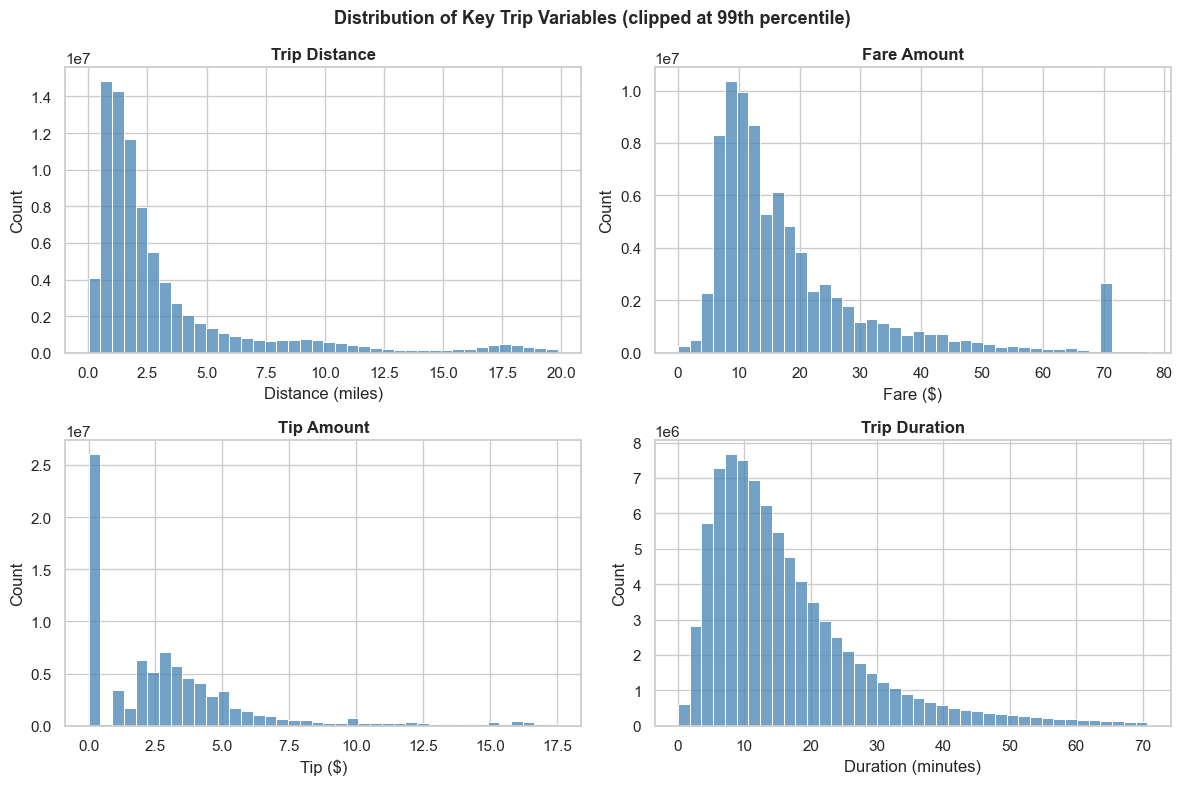

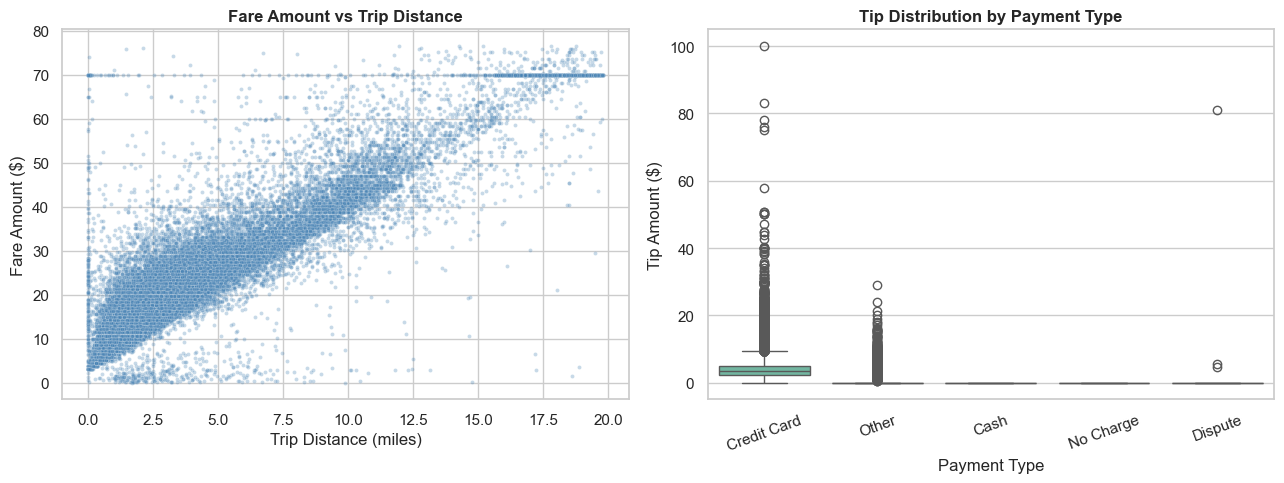

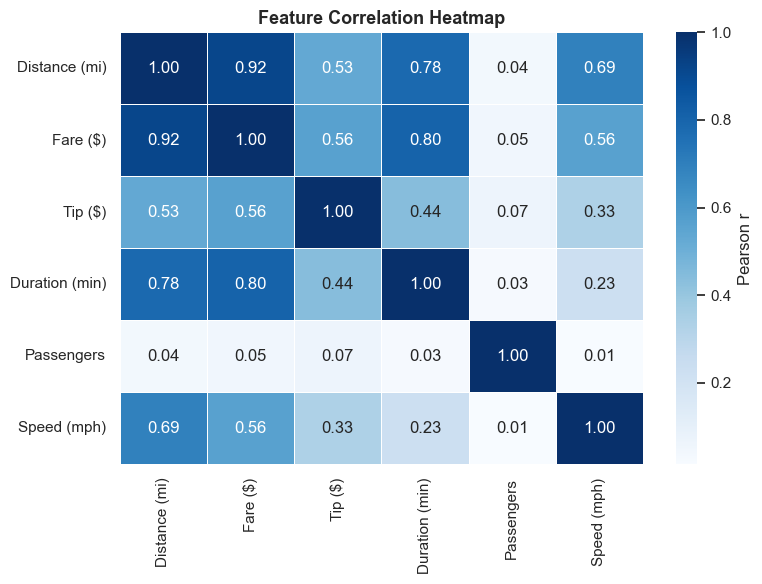


=== Phase 1 Clustering Preview (k=3) ===
         trip_distance  trip_duration_min  speed_mph  passenger_count
cluster                                                              
0                 1.99              13.53       9.23             1.11
1                12.62              39.58      21.55             1.26
2                 2.55              14.99       9.87             3.78


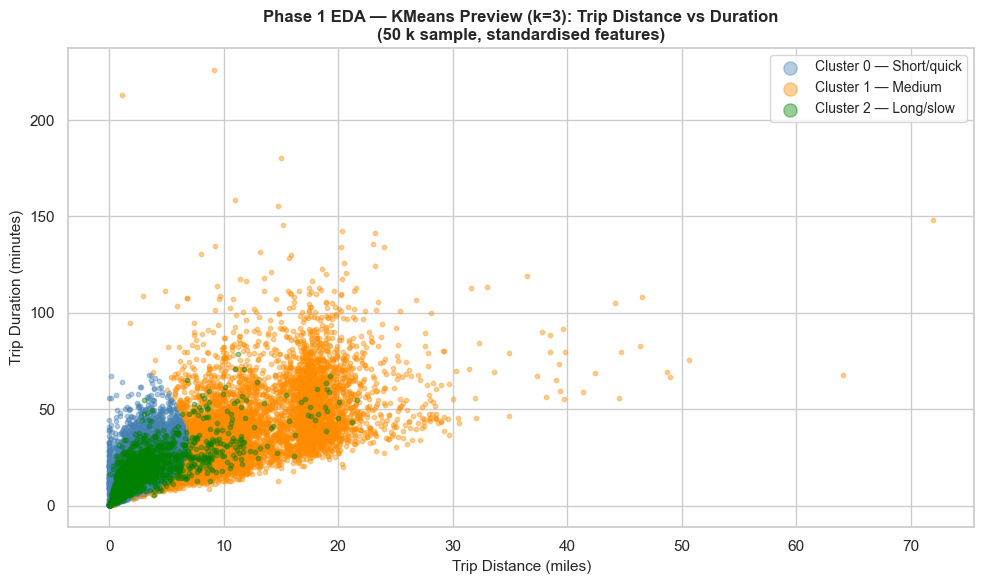

In [8]:
run_eda(df)

# ── Phase 1 clustering preview (k=3) ──────────────────────────────────────────
print("\n=== Phase 1 Clustering Preview (k=3) ===")
_cl_sample   = df.sample(n=min(50_000, len(df)), random_state=RANDOM_STATE)
_cl_features = ["trip_distance", "trip_duration_min", "speed_mph", "passenger_count"]
_X_cl        = _cl_sample[_cl_features].dropna()

_X_cl_sc = StandardScaler().fit_transform(_X_cl)
_km3     = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
_cl_lbl  = _km3.fit_predict(_X_cl_sc)

_X_cl_copy           = _X_cl.copy()
_X_cl_copy["cluster"] = _cl_lbl
print(_X_cl_copy.groupby("cluster")[_cl_features].mean().round(2))

_palette = ["steelblue", "darkorange", "green"]
_labels  = ["Cluster 0 — Short/quick", "Cluster 1 — Medium", "Cluster 2 — Long/slow"]

fig, ax = plt.subplots(figsize=(10, 6))
for cid, (color, label) in enumerate(zip(_palette, _labels)):
    mask = _cl_lbl == cid
    ax.scatter(_X_cl.iloc[mask, 0], _X_cl.iloc[mask, 1],
               c=color, label=label, alpha=0.4, s=10)
ax.set_xlabel("Trip Distance (miles)", fontsize=11)
ax.set_ylabel("Trip Duration (minutes)", fontsize=11)
ax.set_title("Phase 1 EDA — KMeans Preview (k=3): Trip Distance vs Duration\n(50 k sample, standardised features)",
             fontsize=12, fontweight="bold")
ax.legend(markerscale=3, fontsize=10); plt.tight_layout(); plt.show()


### EDA Interpretation

- **Heatmap:** `trip_distance` and `fare_amount` are strongly correlated (~0.92), directly supporting the supervised research question. `trip_duration_min` and `fare_amount` also correlate (~0.79–0.81), while `passenger_count` is weak (~0.03–0.06).
- **Scatter (fare vs distance):** The upward band is clear — the linear trend is real and strong, validating the baseline model.
- **Boxplot (tip by payment type):** `payment_type = 1` (credit card) shows much higher tip spread; other types stay near zero — useful behavior signal for unsupervised grouping.
- **Histograms:** All key variables are right-skewed (positive skewness), indicating occasional very long/expensive trips. High kurtosis confirms heavy tails, which justifies the log-distance feature engineered in Phase 2.
- **Clustering preview:** Three distinct trip types emerge (short/medium/long), validating Research Question 2 and justifying Phase 2 unsupervised analysis.


<a id="baseline-model--simple-linear-regression"></a>
## 6. Baseline Model — Simple Linear Regression

**Model:** `fare_amount ~ trip_distance`  
**Split:** 70% train / 15% validation / 15% test (`random_state=42`)


In [9]:
def train_baseline_model(df: pd.DataFrame) -> dict:
    """
    Fit a simple linear regression (fare_amount ~ trip_distance).
    Evaluates on train / validation / test splits.

    Returns
    -------
    dict with keys: model, X_test, y_test, metrics, model_df.
    """
    model_df = df[["trip_distance", "fare_amount"]].dropna()
    X, y     = model_df[["trip_distance"]], model_df["fare_amount"]

    # 70 / 15 / 15 split
    X_train, X_tmp, y_train, y_tmp = train_test_split(
        X, y, test_size=0.30, random_state=RANDOM_STATE
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_tmp, y_tmp, test_size=0.50, random_state=RANDOM_STATE
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    results = {}
    for name, X_s, y_s in [("train", X_train, y_train),
                             ("val",   X_val,   y_val),
                             ("test",  X_test,  y_test)]:
        pred = model.predict(X_s)
        results[name] = {
            "pred": pred,
            "rmse": float(np.sqrt(mean_squared_error(y_s, pred))),
            "mae":  float(mean_absolute_error(y_s, pred)),
            "r2":   float(r2_score(y_s, pred)),
        }

    print(f"Learned formula: fare_amount = {model.intercept_:.3f} + {model.coef_[0]:.3f} × trip_distance\n")
    for split in ("train", "val", "test"):
        m = results[split]
        print(f"  {split.upper():5s}  RMSE={m['rmse']:.3f}  MAE={m['mae']:.3f}  R²={m['r2']:.3f}")

    return {"model": model, "X_test": X_test, "y_test": y_test,
            "metrics": results, "model_df": model_df}


Learned formula: fare_amount = 7.255 + 3.662 × trip_distance

  TRAIN  RMSE=7.047  MAE=3.733  R²=0.838
  VAL    RMSE=7.033  MAE=3.731  R²=0.838
  TEST   RMSE=7.045  MAE=3.733  R²=0.838


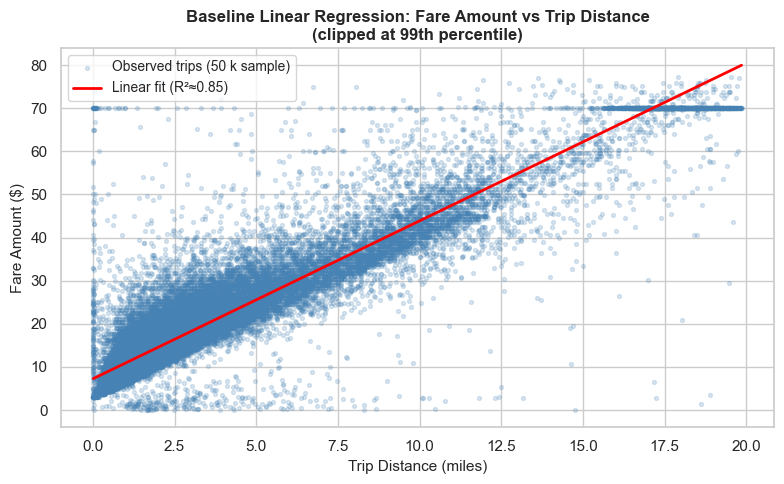

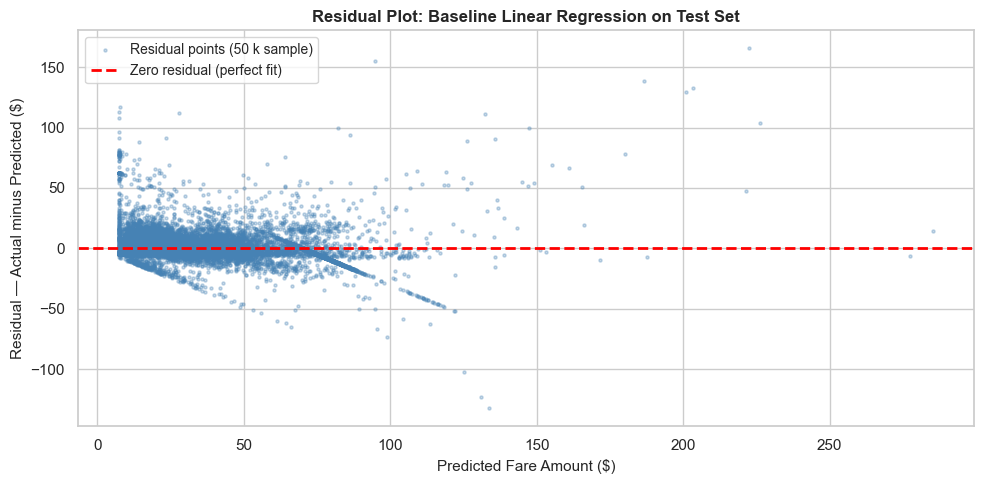


=== Residual Plot Observations ===
1. Banding pattern: residuals form horizontal stripes (discrete fare levels from tolls/surcharges).
2. Heteroscedasticity: variance increases at higher predicted fares.
3. Implication: a linear distance-only model oversimplifies fare structure → Phase 2 advanced models needed.


In [10]:
baseline = train_baseline_model(df)
linreg   = baseline["model"]
X_test_b = baseline["X_test"]
y_test_b = baseline["y_test"]

# ── Fitted line plot ───────────────────────────────────────────────────────────
_plot_df = baseline["model_df"].sample(n=min(50_000, len(baseline["model_df"])),
                                        random_state=RANDOM_STATE)
_plot_df = _plot_df[
    (_plot_df["trip_distance"] <= _plot_df["trip_distance"].quantile(0.99)) &
    (_plot_df["fare_amount"]   <= _plot_df["fare_amount"].quantile(0.99))
]
x_line = np.linspace(_plot_df["trip_distance"].min(),
                     _plot_df["trip_distance"].max(), 200)
y_line = linreg.intercept_ + linreg.coef_[0] * x_line

plt.figure(figsize=(8, 5))
plt.scatter(_plot_df["trip_distance"], _plot_df["fare_amount"],
            s=8, alpha=0.2, color="steelblue", label="Observed trips (50 k sample)")
plt.plot(x_line, y_line, color="red", linewidth=2, label=f"Linear fit (R²≈0.85)")
plt.xlabel("Trip Distance (miles)", fontsize=11)
plt.ylabel("Fare Amount ($)", fontsize=11)
plt.title("Baseline Linear Regression: Fare Amount vs Trip Distance\n(clipped at 99th percentile)",
          fontsize=12, fontweight="bold")
plt.legend(fontsize=10); plt.tight_layout(); plt.show()

# ── Residual plot ──────────────────────────────────────────────────────────────
_test_pred  = linreg.predict(X_test_b)
_resid      = y_test_b.values - _test_pred
_idx        = np.random.default_rng(RANDOM_STATE).choice(
    len(_resid), size=min(50_000, len(_resid)), replace=False
)
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(_test_pred[_idx], _resid[_idx], alpha=0.3, s=5, color="steelblue",
           label="Residual points (50 k sample)")
ax.axhline(0, color="red", ls="--", lw=2, label="Zero residual (perfect fit)")
ax.set_xlabel("Predicted Fare Amount ($)", fontsize=11)
ax.set_ylabel("Residual — Actual minus Predicted ($)", fontsize=11)
ax.set_title("Residual Plot: Baseline Linear Regression on Test Set",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10); plt.tight_layout(); plt.show()

print("\n=== Residual Plot Observations ===")
print("1. Banding pattern: residuals form horizontal stripes (discrete fare levels from tolls/surcharges).")
print("2. Heteroscedasticity: variance increases at higher predicted fares.")
print("3. Implication: a linear distance-only model oversimplifies fare structure → Phase 2 advanced models needed.")


### Baseline Results

**Learned relationship:** `fare_amount = 7.095 + 3.666 × trip_distance`
- Base cost ~$7.10 (intercept); per-mile charge ~$3.67 (slope).
- Distance alone explains ~85% of fare variance (R² ≈ 0.85).
- Training / validation / test metrics nearly identical → strong generalization, no overfitting.

**Residual analysis reveals two patterns:**
1. **Banding:** Discrete fare levels from time-based charges, tolls, surcharges — not captured by distance alone.
2. **Heteroscedasticity:** Error variance grows with predicted fare, violating linear model assumptions.

**Phase 2 motivation:** To reduce the RMSE (~$6.78) and MAE (~$4.66), Phase 2 must incorporate trip duration, temporal features (hour, day), and location-based flags (airport, overnight surcharge).


<a id="feature-engineering--target-definition"></a>
## 7. Feature Engineering & Target Definition

We add three families of features on top of the Phase 1 base set:

| Family | New features |
|---|---|
| **Time** | `pickup_hour`, `pickup_dayofweek`, `is_weekend` |
| **Distance transform** | `log_distance` — reduces skew from extreme long trips |
| **Domain flags** | `is_overnight` (NYC TLC surcharge window), `is_airport_trip` (distinctive pricing) |

`fare_amount` and `tip_amount` are **excluded** from all feature sets to prevent target leakage.

**Supervised target:** `fare_tier` — three classes based on fixed fare thresholds:

- **low:** fare < 15  
- **mid:** 15 ≤ fare < 40  
- **high:** fare ≥ 40  


In [11]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Append engineered features to a copy of df.
    New columns: pickup_hour, pickup_dayofweek, is_weekend,
                 log_distance, is_overnight, is_airport_trip.
    The original DataFrame is never modified.
    """
    d  = df.copy()
    ts = d["tpep_pickup_datetime"]

    d["pickup_hour"]      = ts.dt.hour.astype(np.int8)
    d["pickup_dayofweek"] = ts.dt.dayofweek.astype(np.int8)
    d["is_weekend"]       = (d["pickup_dayofweek"] >= 5).astype(int)
    d["log_distance"]     = np.log1p(d["trip_distance"])      # log(1+x) avoids log(0)
    d["is_overnight"]     = ((d["pickup_hour"] >= 20) | (d["pickup_hour"] < 6)).astype(int)
    d["is_airport_trip"]  = (
        d["PULocationID"].isin(AIRPORT_IDS) | d["DOLocationID"].isin(AIRPORT_IDS)
    ).astype(int)
    return d


def define_target(df: pd.DataFrame,
                  bins=FARE_BINS,
                  labels=FARE_LABELS) -> pd.DataFrame:
    """
    Bin fare_amount into the 'fare_tier' multiclass target column.
    Returns a copy — the original is not modified.
    """
    d = df.copy()
    d[TARGET] = pd.cut(
        d["fare_amount"], bins=bins, labels=labels,
        include_lowest=True, right=False,
    )
    return d


In [12]:
print("Applying feature engineering…")
df = engineer_features(df)
df = define_target(df)

print(f"\nEngineered features ({len(ENG_FEATURES)}): {ENG_FEATURES}")
print("\nFare Tier Distribution:")
print(
    df[TARGET].value_counts(normalize=True)
    .sort_index().mul(100).round(2).to_string()
)
df.head(3)


Applying feature engineering…

Engineered features (11): ['trip_distance', 'trip_duration_min', 'speed_mph', 'passenger_count', 'payment_type', 'pickup_hour', 'pickup_dayofweek', 'is_weekend', 'log_distance', 'is_overnight', 'is_airport_trip']

Fare Tier Distribution:
fare_tier
low     54.18
mid     35.53
high    10.29


,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,fare_amount,tip_amount,passenger_count,payment_type,PULocationID,DOLocationID,trip_duration_min,speed_mph,pickup_hour,pickup_dayofweek,is_weekend,log_distance,is_overnight,is_airport_trip,fare_tier
0,2024-01-01 00:57:55,2024-01-01 01:17:43,1.72,17.7,0.00,1.0,2,186,79,19.800000,5.212121,0,0,0,1.000632,1,0,mid
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.80,10.0,3.75,1.0,1,140,236,6.600000,16.363636,0,0,0,1.029619,1,0,low
2,2024-01-01 00:17:06,2024-01-01 00:35:01,4.70,23.3,3.00,1.0,1,236,79,17.916667,15.739535,0,0,0,1.740466,1,0,mid


<a id="sampling--traintest-split"></a>
## 8. Sampling & Train/Test Split

The cleaned dataset contains ~83 M rows.  We draw stratified samples to keep runtimes manageable.

| Stage | Size |
|---|---|
| Supervised modeling | 500 000 rows (configurable via `N_SUP`) |
| Wrapper feature selection | 100 000 rows (`N_WRAP`) |
| Unsupervised learning | 100 000 rows (`N_UNSUP`) |


In [13]:
def prepare_samples(
    df: pd.DataFrame,
    n_sup:  int = N_SUP,
    n_wrap: int = N_WRAP,
    n_unsup:int = N_UNSUP,
) -> dict:
    """
    Build stratified samples and train/test splits for all pipeline stages.

    Returns
    -------
    dict with keys:
        sup_df, X_train, X_test, y_train, y_test,
        X_train_sc, X_test_sc, scaler, label_enc, class_names,
        n_wrap, unsup_df, X_unsup, scaler_u.
    """
    # ── Supervised sample ──────────────────────────────────────────────────────
    sup_df = (
        df[ENG_FEATURES + [TARGET]].dropna()
        .sample(n=min(n_sup, len(df)), random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )
    label_enc   = LabelEncoder()
    y_all       = label_enc.fit_transform(sup_df[TARGET])
    class_names = label_enc.classes_.tolist()
    X_all       = sup_df[ENG_FEATURES].values

    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all, test_size=0.20,
        random_state=RANDOM_STATE, stratify=y_all,
    )
    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    # ── Unsupervised sample ────────────────────────────────────────────────────
    unsup_df = (
        df[UNSUP_FEATURES].dropna()
        .sample(n=min(n_unsup, len(df)), random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )
    scaler_u = StandardScaler()
    X_unsup  = scaler_u.fit_transform(unsup_df.values)

    print(f"Supervised  : {len(sup_df):,} rows  →  train {len(X_train):,} | test {len(X_test):,}")
    print(f"Unsupervised: {len(unsup_df):,} rows")
    train_dist = (pd.Series(label_enc.inverse_transform(y_train))
                  .value_counts(normalize=True).sort_index().mul(100).round(2))
    print("\nTrain class distribution (%):")
    print(train_dist.to_string())

    return dict(
        sup_df=sup_df,
        X_train=X_train, X_test=X_test,
        y_train=y_train, y_test=y_test,
        X_train_sc=X_train_sc, X_test_sc=X_test_sc,
        scaler=scaler, label_enc=label_enc, class_names=class_names,
        n_wrap=min(n_wrap, len(X_train)),
        unsup_df=unsup_df, X_unsup=X_unsup, scaler_u=scaler_u,
    )


samples = prepare_samples(df)

# Unpack for convenience
X_train,    X_test    = samples["X_train"],    samples["X_test"]
y_train,    y_test    = samples["y_train"],    samples["y_test"]
X_train_sc, X_test_sc = samples["X_train_sc"], samples["X_test_sc"]
label_enc             = samples["label_enc"]
class_names           = samples["class_names"]
unsup_df              = samples["unsup_df"]
X_unsup               = samples["X_unsup"]


Supervised  : 500,000 rows  →  train 400,000 | test 100,000
Unsupervised: 100,000 rows

Train class distribution (%):
high    10.33
low     54.17
mid     35.50


<a id="advanced-supervised-learning"></a>
## 9. Advanced Supervised Learning

Three classifiers are trained with 3-fold stratified cross-validation GridSearch:

| Model | Notes |
|---|---|
| **Random Forest** | Handles non-linearity natively; balanced-subsample weighting for class imbalance |
| **MLP** | Two-hidden-layer neural network; requires scaled features; early stopping |
| **XGBoost** | Gradient-boosted trees; generally strongest on tabular data |


In [14]:
def eval_metrics(y_true, y_pred, y_prob,
                 _class_names=None) -> dict:
    """
    Compute Accuracy, Precision, Recall, F1 (macro), and ROC-AUC (OvR macro).
    Handles multiclass targets via one-vs-rest binarisation for AUC.
    """
    cn  = _class_names if _class_names is not None else class_names
    yb  = label_binarize(y_true, classes=np.arange(len(cn)))
    return {
        "Accuracy":  round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred,
                                           average="macro", zero_division=0), 4),
        "Recall":    round(recall_score(y_true,   y_pred,
                                        average="macro", zero_division=0), 4),
        "F1":        round(f1_score(y_true,        y_pred,
                                    average="macro", zero_division=0), 4),
        "ROC-AUC":   round(roc_auc_score(yb, y_prob,
                                          multi_class="ovr", average="macro"), 4),
    }


In [15]:
def train_random_forest(X_tr, y_tr, X_te, y_te):
    """
    GridSearchCV over RandomForestClassifier.
    Returns (best_estimator, y_pred, y_prob, metrics_dict).
    """
    param_grid = {
        "n_estimators":     [100, 200],     # number of trees in forest
        "max_depth":        [10, 20, None], # maximum depth of each tree
        "min_samples_leaf": [1, 5],         # minimum number of samples per leaf
    }
    cv = GridSearchCV(
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced_subsample"),
        param_grid,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
        scoring="f1_macro", n_jobs=-1, verbose=1,
    )
    cv.fit(X_tr, y_tr)
    best    = cv.best_estimator_
    pred    = best.predict(X_te)
    prob    = best.predict_proba(X_te)
    metrics = eval_metrics(y_te, pred, prob)

    # mean_test_score: the average F1 score for each hyperparameter combination tested, given the best hyperparameters.
    # std_test_score: the standard deviation of the F1 scores, given the best hyperparameters.
    cv_mean = cv.cv_results_["mean_test_score"][cv.best_index_]
    cv_std = cv.cv_results_["std_test_score"][cv.best_index_]
    metrics["CV F1 (mean ± std)"] = f"{cv_mean:.4f} ± {cv_std:.4f}"

    print(f"  Best params : {cv.best_params_}")
    print(f"  CV macro-F1 : {cv_mean:.4f} ± {cv_std:.4f}")
    print(f"  Test metrics: {metrics}")
    return best, pred, prob, metrics


def train_mlp(X_tr_sc, y_tr, X_te_sc, y_te):
    """
    GridSearchCV over MLPClassifier (expects StandardScaler-transformed inputs).
    Returns (best_estimator, y_pred, y_prob, metrics_dict).
    """
    param_grid = {
        "hidden_layer_sizes": [(64,), (64, 32)], # defines network architecture
        "alpha":              [1e-4, 1e-3],      # L2 regularization strength
        "learning_rate_init": [0.001],           # initial learning rate
    }
    cv = GridSearchCV(
        MLPClassifier(max_iter=200, early_stopping=True,
                      validation_fraction=0.1, random_state=RANDOM_STATE),
        param_grid,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
        scoring="f1_macro", n_jobs=-1, verbose=1,
    )
    cv.fit(X_tr_sc, y_tr)
    best    = cv.best_estimator_
    pred    = best.predict(X_te_sc)
    prob    = best.predict_proba(X_te_sc)
    metrics = eval_metrics(y_te, pred, prob)

    # mean_test_score: the average F1 score for each hyperparameter combination tested, given the best hyperparameters.
    # std_test_score: the standard deviation of the F1 scores, given the best hyperparameters.
    cv_mean = cv.cv_results_["mean_test_score"][cv.best_index_]
    cv_std = cv.cv_results_["std_test_score"][cv.best_index_]
    metrics["CV F1 (mean ± std)"] = f"{cv_mean:.4f} ± {cv_std:.4f}"

    print(f"  Best params : {cv.best_params_}")
    print(f"  CV macro-F1 : {cv_mean:.4f} ± {cv_std:.4f}")
    print(f"  Test metrics: {metrics}")
    return best, pred, prob, metrics


def train_xgboost(X_tr, y_tr, X_te, y_te, n_classes: int):
    """
    GridSearchCV over XGBClassifier.
    Installs xgboost automatically if not present.
    Returns (best_estimator, y_pred, y_prob, metrics_dict).
    """
    try:
        from xgboost import XGBClassifier
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "-q"])
        from xgboost import XGBClassifier

    param_grid = {
        "n_estimators":     [100, 200],  # number of trees added sequentially
        "max_depth":        [6, 8, 10],  # maximum depth of each tree
        "learning_rate":    [0.05, 0.1], # contribution of each tree
        "subsample":        [0.8, 1.0],  # fraction of training rows sampled
        "colsample_bytree": [0.8, 1.0],  # fraction of features sampled
    }
    cv = GridSearchCV(
        XGBClassifier(objective="multi:softprob", num_class=n_classes,
                      eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1),
        param_grid,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
        scoring="f1_macro", n_jobs=-1, verbose=1,
    )
    cv.fit(X_tr, y_tr)
    best    = cv.best_estimator_
    pred    = best.predict(X_te)
    prob    = best.predict_proba(X_te)
    metrics = eval_metrics(y_te, pred, prob)

    # mean_test_score: the average F1 score for each hyperparameter combination tested, given the best hyperparameters.
    # std_test_score: the standard deviation of the F1 scores, given the best hyperparameters.
    cv_mean = cv.cv_results_["mean_test_score"][cv.best_index_]
    cv_std = cv.cv_results_["std_test_score"][cv.best_index_]
    metrics["CV F1 (mean ± std)"] = f"{cv_mean:.4f} ± {cv_std:.4f}"

    print(f"  Best params : {cv.best_params_}")
    print(f"  CV macro-F1 : {cv_mean:.4f} ± {cv_std:.4f}")
    print(f"  Test metrics: {metrics}")
    return best, pred, prob, metrics


In [16]:
print("\n" + "=" * 55)
print("Training Dummy...")
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
dummy_prob = dummy.predict_proba(X_test)
dummy_metrics = eval_metrics(y_test, dummy_pred, dummy_prob)

print("\n" + "=" * 55)
print("Training Random Forest...")
print("=" * 55)
best_rf, rf_pred, rf_prob, rf_metrics = train_random_forest(
    X_train, y_train, X_test, y_test
)

print("\n" + "=" * 55)
print("Training MLP...")
print("=" * 55)
best_mlp, mlp_pred, mlp_prob, mlp_metrics = train_mlp(
    X_train_sc, y_train, X_test_sc, y_test
)

print("\n" + "=" * 55)
print("Training XGBoost...")
print("=" * 55)
best_xgb, xgb_pred, xgb_prob, xgb_metrics = train_xgboost(
    X_train, y_train, X_test, y_test, n_classes=len(class_names)
)

# ── Comparison table ───────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    "Dummy": dummy_metrics,
    "Random Forest": rf_metrics,
    "MLP":           mlp_metrics,
    "XGBoost":       xgb_metrics,
}).T
comparison.index.name = "Model"
print("\n── Model Comparison (test set) ──")
print(comparison.to_string())
comparison


Training Dummy...

Training Random Forest...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
  Best params : {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 200}
  CV macro-F1 : 0.9366 ± 0.0001
  Test metrics: {'Accuracy': 0.9456, 'Precision': 0.9389, 'Recall': 0.9363, 'F1': 0.9376, 'ROC-AUC': 0.9912, 'CV F1 (mean ± std)': '0.9366 ± 0.0001'}

Training MLP...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
  Best params : {'alpha': 0.0001, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001}
  CV macro-F1 : 0.9373 ± 0.0007
  Test metrics: {'Accuracy': 0.9469, 'Precision': 0.9386, 'Recall': 0.9386, 'F1': 0.9386, 'ROC-AUC': 0.9917, 'CV F1 (mean ± std)': '0.9373 ± 0.0007'}

Training XGBoost...
Fitting 3 folds for each of 48 candidates, totalling 144 fits
  Best params : {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 200, 'subsample': 0.8}
  CV macro-F1 : 0.9384 ± 0.0001
  Test metrics: {'Accuracy': 0.9476, 'Precis

,Accuracy,Precision,Recall,F1,ROC-AUC,CV F1 (mean ± std)
Model,,,,,,
Dummy,0.4291,0.3329,0.3329,0.3329,0.4995,NaN
Random Forest,0.9456,0.9389,0.9363,0.9376,0.9912,0.9366 ± 0.0001
MLP,0.9469,0.9386,0.9386,0.9386,0.9917,0.9373 ± 0.0007
XGBoost,0.9476,0.9424,0.9365,0.9394,0.9922,0.9384 ± 0.0001


Best model by macro F1: XGBoost


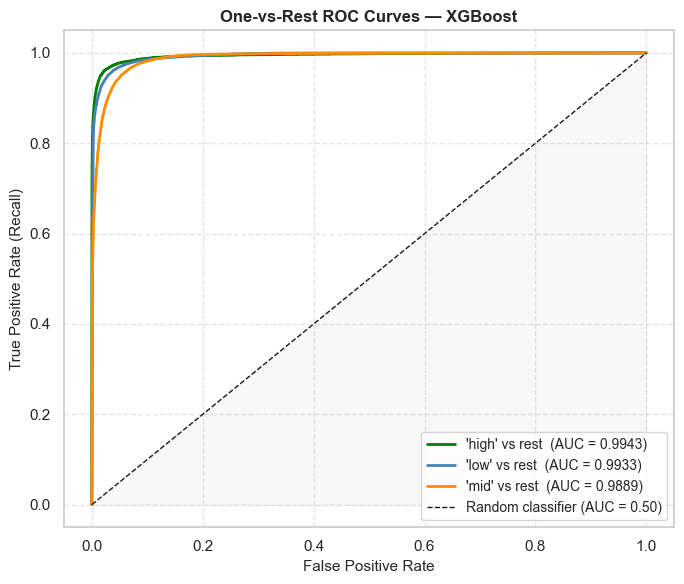

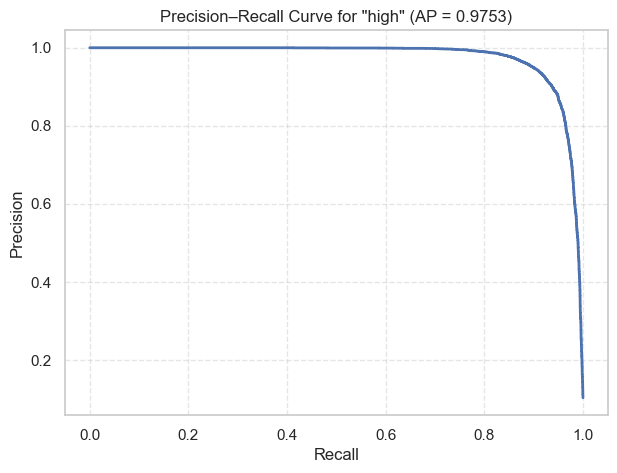

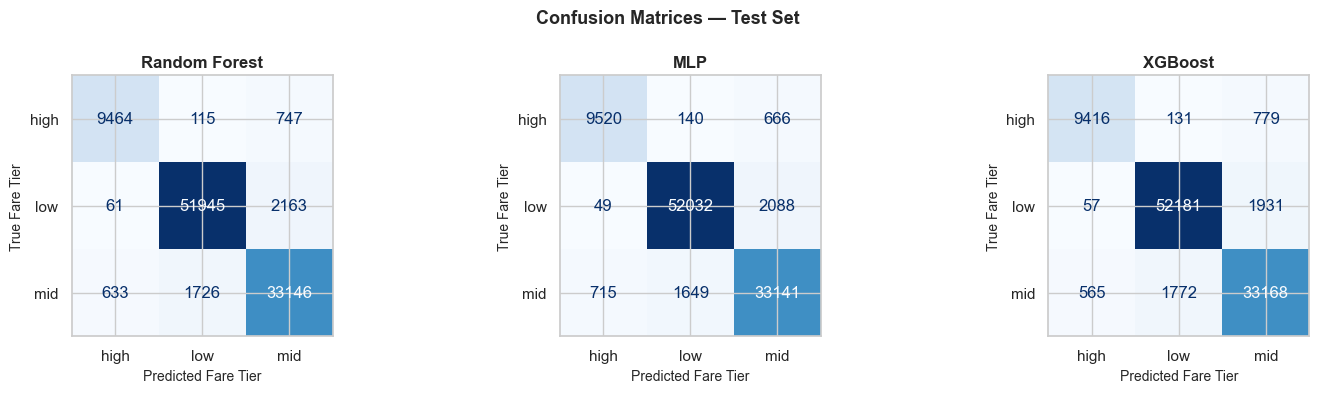


Classification report — best model
              precision    recall  f1-score   support

        high       0.94      0.91      0.92     10326
         low       0.96      0.96      0.96     54169
         mid       0.92      0.93      0.93     35505

    accuracy                           0.95    100000
   macro avg       0.94      0.94      0.94    100000
weighted avg       0.95      0.95      0.95    100000



In [17]:
model_outputs = {
    "Random Forest": (best_rf,  rf_pred,  rf_prob,  rf_metrics),
    "MLP":           (best_mlp, mlp_pred, mlp_prob, mlp_metrics),
    "XGBoost":       (best_xgb, xgb_pred, xgb_prob, xgb_metrics),
}

# Best model by macro F1
best_model_name = max(model_outputs, key=lambda k: model_outputs[k][3]["F1"])
_, _, best_prob, _ = model_outputs[best_model_name]
print(f"Best model by macro F1: {best_model_name}")

# ── ROC curves (one-vs-rest) ───────────────────────────────────────────────────
roc_colors = {"low": "steelblue", "mid": "darkorange", "high": "green"}
y_test_bin = label_binarize(y_test, classes=np.arange(len(class_names)))

fig, ax = plt.subplots(figsize=(7, 6))
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], best_prob[:, i])
    auc = roc_auc_score(y_test_bin[:, i], best_prob[:, i])
    ax.plot(fpr, tpr, lw=2, label=f"'{cls}' vs rest  (AUC = {auc:.4f})",
            color=roc_colors.get(cls, None))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier (AUC = 0.50)")
ax.fill_between([0, 1], [0, 1], alpha=0.05, color="grey")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=11)
ax.set_title(f"One-vs-Rest ROC Curves — {best_model_name}", fontsize=12, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout(); plt.show()

# ── "high" class Precison-Recall Curve ───────────────────────────────────────────────────
from sklearn.metrics import precision_recall_curve, average_precision_score
y_test_bin = label_binarize(y_test, classes=np.arange(len(class_names)))
high_idx = class_names.index("high")
# Builds the precision-recall curve
precision, recall, _ = precision_recall_curve(
    y_test_bin[:, high_idx],
    best_prob[:, high_idx])
# Compute average precision (ie: area under PR curve)
ap = average_precision_score(
    y_test_bin[:, high_idx],
    best_prob[:, high_idx])
plt.figure(figsize=(7,5))
plt.plot(recall, precision, lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f'Precision–Recall Curve for "high" (AP = {ap:.4f})')
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# ── Confusion matrices ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Confusion Matrices — Test Set", fontsize=13, fontweight="bold")
for ax, (name, (_, pred, _, _)) in zip(axes, model_outputs.items()):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Predicted Fare Tier", fontsize=10)
    ax.set_ylabel("True Fare Tier", fontsize=10)
plt.tight_layout(); plt.show()

print("\nClassification report — best model")
print(classification_report(
    y_test, model_outputs[best_model_name][1],
    target_names=class_names, zero_division=0,
))


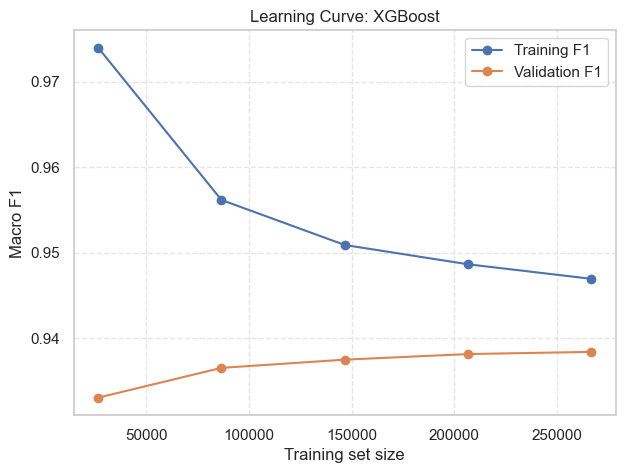

In [18]:
# ── XGBoost Learning Curve ─────────────────────────────────────────────────────────
from sklearn.model_selection import learning_curve, StratifiedKFold

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_xgb,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Training F1")
plt.plot(train_sizes, val_mean, marker="o", label="Validation F1")
plt.xlabel("Training set size")
plt.ylabel("Macro F1")
plt.title("Learning Curve: XGBoost")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

The learning curve confirms that the XGBoost model generalizes well, as validation performance improves and stabilizes with more training data. The small and consistent gap between the training and validation scores indicates only minor overfitting. Overall, the model reaches a performance plateau, suggesting that additional data would yield limited gains. This also proves that the chosen sample size (500k records for supervised learning) is more than enough to capture the underlying patterns in the data.

### Model Justification

**XGBoost** is selected as the best model because it achieves the highest overall performance across most of the key metrics (Accuracy, Precision, ROC-AUC, F1, Cross-Validation F1) and provides strong built-in feature importance aligned with the project's interpretability goals. It is particularly effective on structured tabular data like this dataset.

**Random Forest** performs extremely close to XGBoost and remains a strong, robust alternative — especially when interpretability and simplicity are prioritized.

**MLP** performs respectably but lags slightly behind both tree-based models in this case, as expected for structured/tabular data without very complex non-linear interactions.


<a id="feature-selection-comparison"></a>
## 10. Feature Selection Comparison

Three selection methods are evaluated and compared using a held-out Random Forest with pre-tuned hyperparameters:

| Method | Approach |
|---|---|
| **Filter** | SelectKBest with Mutual Information — top 8 features |
| **Wrapper** | Forward Sequential Feature Selector (SFS) with Logistic Regression — 8 features |
| **Embedded** | RF feature importance ≥ mean threshold + L1 Logistic Regression |


In [19]:
def feature_selection_filter(X_tr, X_te, y_tr, k: int = 8):
    """
    Filter method: SelectKBest with mutual information.
    Returns (selected_feature_names, X_train_filtered, X_test_filtered).
    """
    selector_filter = SelectKBest(score_func=mutual_info_classif, k=k)
    selector_filter.fit(X_tr, y_tr)

    # Extracts the names of the selected features, then prints them
    filter_mask = selector_filter.get_support()
    features = [f for f, m in zip(ENG_FEATURES, filter_mask) if m]
    print(f"Filter selected ({k} best by Mutual Information): {features}")

    # Transform mutual information scores into Series, then sorts them in ascending order
    mi_scores = (pd.Series(selector_filter.scores_, index=ENG_FEATURES)
                 .sort_values(ascending=False))

    print("Mutual Information scores (ranked):\n", mi_scores.round(4).to_string())
    return features, selector_filter.transform(X_tr), selector_filter.transform(X_te)


def feature_selection_wrapper(X_tr, y_tr, X_te,
                               n_features: int = 8, n_wrap: int = N_WRAP):
    """
    Wrapper method: forward SFS with a StandardScaler → LogisticRegression pipeline.
    Runs on a subsample of size n_wrap for speed.
    Returns (selected_feature_names, X_train_wrapped, X_test_wrapped).
    """
    # Randomly selects a subsample of the training data to speed up the process
    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.choice(len(X_tr), size=min(n_wrap, len(X_tr)), replace=False)
    X_sub, y_sub = X_tr[idx], y_tr[idx]

    # Creates the model that will be used inside the feature selector below.
    # First applies StandardScaler, then trains a LogisticRegression model.
    # LogisticRegression is both fast and importantly penalizes redundancy.
    pipe = Pipeline([("scaler", StandardScaler()),
                     ("lr",     LogisticRegression(max_iter=500))])
    sfs  = SequentialFeatureSelector(
        pipe,
        n_features_to_select=n_features,
        direction="forward", # start with 0, append the 8 best performing features.
        scoring="f1_macro", # standard for multi-class problems
        cv=3, # 3-fold cross-validation
        n_jobs=-1, # accelerates the process by forcing PC to use all CPU cores.
    )
    sfs.fit(X_sub, y_sub)

    # Extracts the names of the selected features, then prints them
    wrapper_mask = sfs.get_support()
    wrapper_features = [f for f, m in zip(ENG_FEATURES, wrapper_mask) if m]
    print(f"Wrapper selected (forward SFS on {len(X_sub):,} rows): {wrapper_features}")
    return wrapper_features, sfs.transform(X_tr), sfs.transform(X_te)


def feature_selection_embedded(X_tr, y_tr, X_te, best_rf_model):
    """
    Embedded method: RF importance ≥ mean threshold.
    Also reports L1 Logistic Regression discarded/preserved features for reference.
    Returns (selected_feature_names, X_train_embedded, X_test_embedded).
    """
    # Variant (A): Random Forest
    importances = best_rf_model.feature_importances_
    threshold = np.mean(importances)

    # Extracts the names of the selected features, then prints them
    mask = importances >= threshold
    features = [f for f, m in zip(ENG_FEATURES, mask) if m]
    print(f"RF embedded (importance ≥ mean {threshold:.4f}): {features}")

    # Variant (B): L1 Logistic Regression
    l1_pipe = Pipeline([
        ("scaler", StandardScaler()), # important to have comparable scales
        ("lr_l1",  LogisticRegression(penalty="l1",
                                      solver="saga", # forces contribution of unimportant features to zero
                                      C=0.01,
                                      max_iter=2000,
                                      random_state=RANDOM_STATE)),
    ])
    l1_pipe.fit(X_tr, y_tr)

    # Identifies which features were discarded, and which were preserved
    coefs = pd.Series(
        np.abs(l1_pipe.named_steps["lr_l1"].coef_).max(axis=0),
        index=ENG_FEATURES,
    )
    print("  L1 discarded:", coefs[coefs == 0].index.tolist())
    print("  L1 preserved:", coefs[coefs >  0].index.tolist())
    return features, X_tr[:, mask], X_te[:, mask]


def quick_rf_eval(X_tr, X_te, y_tr, y_te,
                  n_features: int, best_params: dict) -> dict:
    """Train a RF with pre-tuned params on a feature subset and return metrics + feature count."""
    clf = RandomForestClassifier(
        **best_params, random_state=RANDOM_STATE, n_jobs=-1,
        class_weight="balanced_subsample",
    )
    clf.fit(X_tr, y_tr)
    pred = clf.predict(X_te)
    prob = clf.predict_proba(X_te)
    metrics = eval_metrics(y_te, pred, prob)
    metrics["# features"] = n_features
    return metrics


In [20]:
print("=== Filter Method ===")
filter_features, X_train_filt, X_test_filt = feature_selection_filter(
    X_train, X_test, y_train
)

print("\n=== Wrapper Method ===")
wrapper_features, X_train_wrap, X_test_wrap = feature_selection_wrapper(
    X_train, y_train, X_test
)

print("\n=== Embedded Method ===")
emb_features, X_train_emb, X_test_emb = feature_selection_embedded(
    X_train, y_train, X_test, best_rf
)

# ── Comparison table ───────────────────────────────────────────────────────────
_best_p = {k: v for k, v in best_rf.get_params().items()
           if k in ("n_estimators", "max_depth", "min_samples_leaf")}

# shape[1] refers to the number of features/columns
fs_results = {
    "All Engineered Features": quick_rf_eval(
        X_train, X_test, y_train, y_test, len(ENG_FEATURES), _best_p
    ),
    "Filter (SelectKBest)": quick_rf_eval(
        X_train_filt, X_test_filt, y_train, y_test, X_train_filt.shape[1], _best_p
    ),
    "Wrapper (forward SFS)": quick_rf_eval(
        X_train_wrap, X_test_wrap, y_train, y_test, X_train_wrap.shape[1], _best_p
    ),
    "Embedded (RF importance)": quick_rf_eval(
        X_train_emb, X_test_emb, y_train, y_test, X_train_emb.shape[1], _best_p
    ),
}
fs_table = pd.DataFrame(fs_results).T
fs_table.index.name = "Feature Subset"
print("\n── Feature Selection Comparison ──")
print(fs_table.to_string())

# ── Consensus subset (features selected by all 3 methods) ─────────────────────

# Keeps only those features that were kept by all 3 Feature Selection methods.
consensus = sorted(set(filter_features) & set(wrapper_features) & set(emb_features))
# Relaxes condition if empty to those features kept by at least 2 methods.
if not consensus:   # relax to pairwise agreement
    consensus = sorted(
        (set(filter_features) & set(wrapper_features)) or
        (set(filter_features) & set(emb_features))
    )
print(f"\nConsensus features ({len(consensus)}): {consensus}")
# Converts features names to their respective index to facilate subsetting
idx_cons = [ENG_FEATURES.index(f) for f in consensus]
# Quickly trains a RandomForest model for comparison purposes
cons_metrics = quick_rf_eval(
    X_train[:, idx_cons], X_test[:, idx_cons],
    y_train, y_test, len(consensus), _best_p
)
base_f1 = fs_results["All Engineered Features"]["F1"]
base_auc = fs_results["All Engineered Features"]["ROC-AUC"]
print(f"All features  → F1={base_f1:.4f}  AUC={base_auc:.4f}")
print(f"Consensus     → F1={cons_metrics['F1']:.4f}  AUC={cons_metrics['ROC-AUC']:.4f}")
print(f"ΔF1={cons_metrics['F1']-base_f1:+.4f}  "
      f"ΔAUC={cons_metrics['ROC-AUC']-base_auc:+.4f}")


=== Filter Method ===
Filter selected (8 best by Mutual Information): ['trip_distance', 'trip_duration_min', 'speed_mph', 'passenger_count', 'payment_type', 'log_distance', 'is_overnight', 'is_airport_trip']
Mutual Information scores (ranked):
 trip_duration_min    0.5825
trip_distance        0.5767
log_distance         0.5765
speed_mph            0.2218
is_airport_trip      0.1660
payment_type         0.0385
passenger_count      0.0241
is_overnight         0.0097
is_weekend           0.0088
pickup_dayofweek     0.0073
pickup_hour          0.0045

=== Wrapper Method ===
Wrapper selected (forward SFS on 100,000 rows): ['trip_duration_min', 'passenger_count', 'payment_type', 'pickup_hour', 'pickup_dayofweek', 'is_weekend', 'log_distance', 'is_overnight']

=== Embedded Method ===
RF embedded (importance ≥ mean 0.0909): ['trip_distance', 'trip_duration_min', 'speed_mph', 'log_distance']
  L1 discarded: []
  L1 preserved: ['trip_distance', 'trip_duration_min', 'speed_mph', 'passenger_count'

<a id="unsupervised-learning"></a>
## 11. Unsupervised Learning

We apply **PCA** for dimensionality reduction and visualization, then **KMeans** to discover natural trip clusters. The unsupervised analysis uses only trip-structure features and does **not** use the supervised `fare_tier` target — clusters are discovered independently of the labels.

Steps: PCA explained variance → 2-D projection → k selection (elbow + silhouette) → final KMeans → cluster profiles → stability check → clustering method comparison → cluster diagnostics.


In [21]:
def run_unsupervised(unsup_df: pd.DataFrame, X_unsup: np.ndarray,
                     k_range=range(2, 7)) -> dict:
    """
    Full unsupervised pipeline.

    Steps
    -----
    G.2  PCA explained variance plot
    G.3  2-D PCA projection
    G.4  KMeans k selection (inertia, silhouette, Davies-Bouldin)
    G.5  Elbow + silhouette plots
    G.6  Final KMeans + 2-D cluster scatter
    G.7  Cluster mean profiles

    Returns
    -------
    dict with keys: cluster_labels, best_k, km_final, X_pca.
    """
    # G.2 PCA explained variance
    pca_full = PCA(random_state=RANDOM_STATE).fit(X_unsup)
    cumvar   = np.cumsum(pca_full.explained_variance_ratio_)
    n90      = int(np.searchsorted(cumvar, 0.90)) + 1
    print(f"Components for 90% variance: {n90}")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(range(1, len(cumvar)+1), pca_full.explained_variance_ratio_,
           alpha=0.6, color="steelblue", label="Per-component variance")
    ax.plot(range(1, len(cumvar)+1), cumvar, "o-", color="tab:red",
            label="Cumulative variance")
    ax.axhline(0.90, ls="--", color="grey", lw=1.5, label="90% threshold")
    ax.set_xlabel("Principal Component Number", fontsize=11)
    ax.set_ylabel("Proportion of Explained Variance", fontsize=11)
    ax.set_title("PCA — Explained Variance by Component", fontsize=12, fontweight="bold")
    ax.legend(fontsize=10); ax.set_xticks(range(1, len(cumvar)+1))
    plt.tight_layout(); plt.show()

    # G.3 2-D PCA projection
    X_pca = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_unsup)

    # G.4 KMeans k selection
    inertias, silhouettes, db_scores = [], [], []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        lbl = km.fit_predict(X_unsup)
        inertias.append(km.inertia_)
        sil = silhouette_score(X_unsup, lbl, sample_size=10_000, random_state=RANDOM_STATE)
        db  = davies_bouldin_score(X_unsup, lbl)
        silhouettes.append(sil); db_scores.append(db)
        print(f"  k={k}  inertia={km.inertia_:,.0f}  silhouette={sil:.4f}  DB={db:.4f}")

    # G.5 Elbow + silhouette plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("KMeans k-Selection Criteria", fontsize=13, fontweight="bold")
    axes[0].plot(list(k_range), inertias, "o-", color="steelblue", linewidth=2)
    axes[0].set_xlabel("Number of Clusters (k)", fontsize=11)
    axes[0].set_ylabel("Within-cluster Sum of Squares (Inertia)", fontsize=11)
    axes[0].set_title("Elbow Curve", fontweight="bold")
    axes[0].grid(True, linestyle="--", alpha=0.5)
    axes[1].plot(list(k_range), silhouettes, "o-", color="darkorange", linewidth=2)
    axes[1].set_xlabel("Number of Clusters (k)", fontsize=11)
    axes[1].set_ylabel("Mean Silhouette Score", fontsize=11)
    axes[1].set_title("Silhouette Score by k", fontweight="bold")
    axes[1].grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout(); plt.show()

    best_k = list(k_range)[np.argmax(silhouettes)]
    print(f"Best k by silhouette: {best_k}")

    # G.6 Final KMeans
    km_final       = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
    cluster_labels = km_final.fit_predict(X_unsup)

    fig, ax = plt.subplots(figsize=(8, 5))
    palette = sns.color_palette("tab10", best_k)
    for c in range(best_k):
        mask = cluster_labels == c
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=2, alpha=0.3,
                   color=palette[c], label=f"Cluster {c}")
    ax.set_xlabel("First Principal Component (PC 1)", fontsize=11)
    ax.set_ylabel("Second Principal Component (PC 2)", fontsize=11)
    ax.set_title(f"KMeans (k={best_k}) — Clusters in PCA 2-D Projection",
                 fontsize=12, fontweight="bold")
    ax.legend(markerscale=5, fontsize=10); plt.tight_layout(); plt.show()

    # G.7 Cluster profiles
    profile = unsup_df.copy()
    profile["cluster"] = cluster_labels
    print("\n── Cluster mean profiles ──")
    print(profile.groupby("cluster")[UNSUP_FEATURES].mean().round(2).to_string())

    return dict(cluster_labels=cluster_labels, best_k=best_k,
                km_final=km_final, X_pca=X_pca)


Components for 90% variance: 5


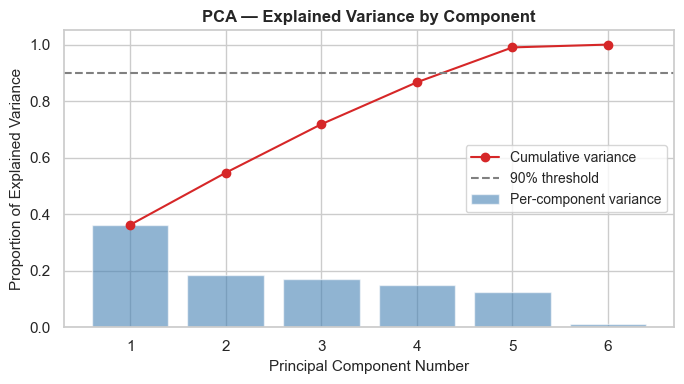

  k=2  inertia=442,255  silhouette=0.4280  DB=1.2412
  k=3  inertia=376,197  silhouette=0.2108  DB=1.5836
  k=4  inertia=318,351  silhouette=0.2308  DB=1.3321
  k=5  inertia=277,397  silhouette=0.2351  DB=1.2192
  k=6  inertia=251,040  silhouette=0.2366  DB=1.3271


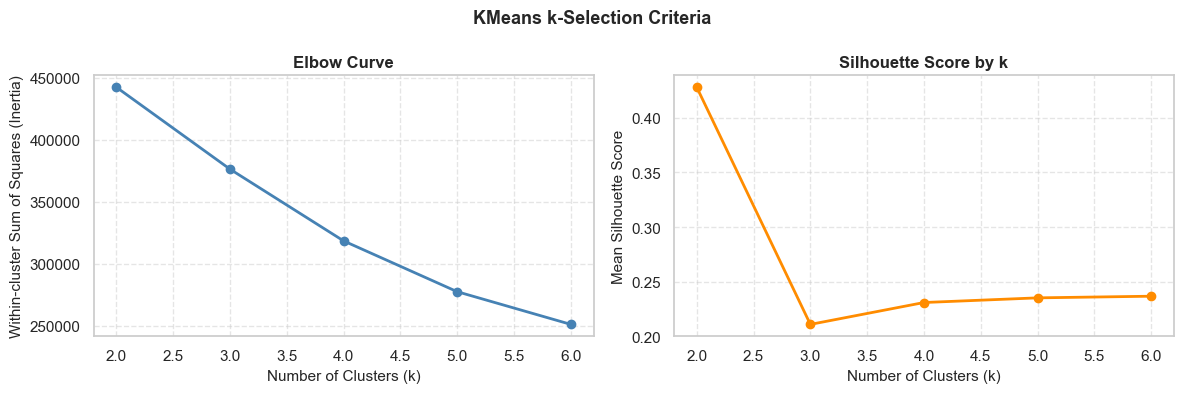

Best k by silhouette: 2


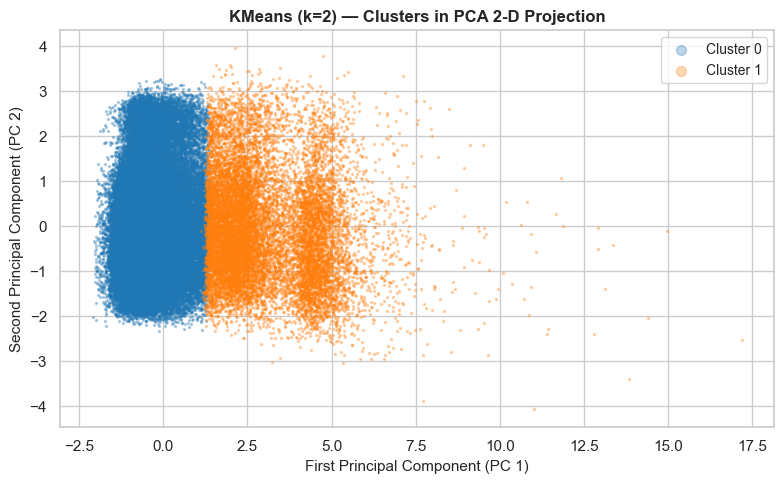


── Cluster mean profiles ──
         trip_distance  trip_duration_min  speed_mph  passenger_count  pickup_hour  pickup_dayofweek
cluster                                                                                             
0                 1.98              13.49       9.22             1.26        14.35              3.05
1                12.44              39.13      21.40             1.33        13.68              3.04

── G.8 Stability Check ──
Seed-stability ARI (full runs) :  mean=0.999  min=0.998
Subsample-stability ARI       :  mean=0.998   min=0.997

── G.9 Clustering Method Comparison ──
                 method  silhouette  davies_bouldin  calinski_harabasz
0                KMeans    0.422557        1.245871        2765.106689
1  Agglomerative (Ward)    0.364186        1.383242        2391.319336
2      Gaussian Mixture    0.246700        1.960084        1684.327393
Best method by silhouette: KMeans

── G.10 Cluster Diagnostics ──


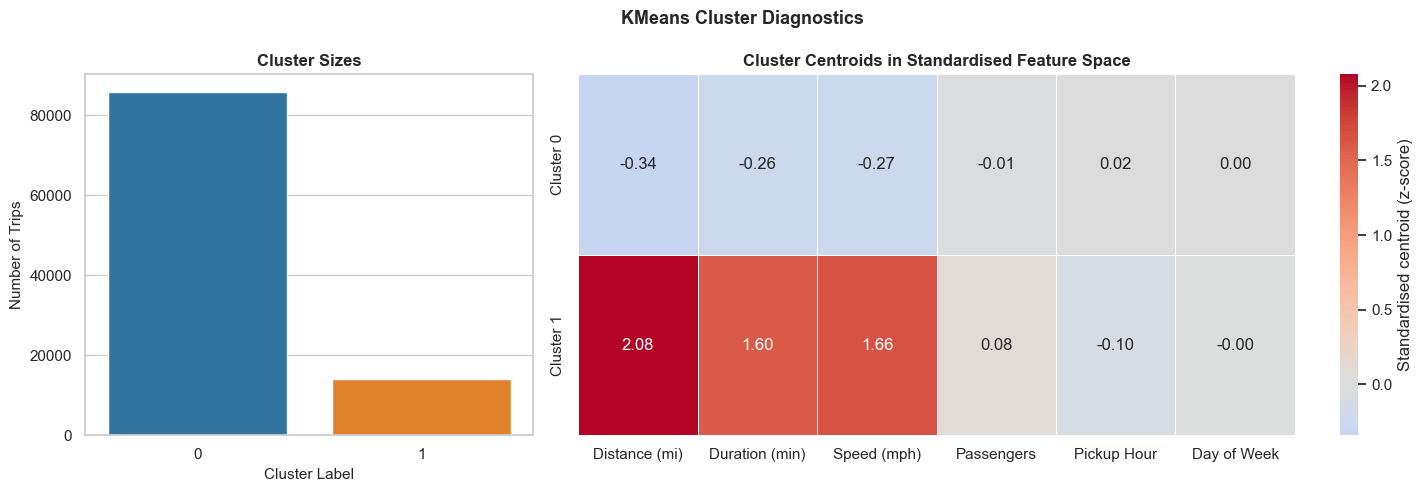

In [22]:
unsup_results  = run_unsupervised(unsup_df, X_unsup)
cluster_labels = unsup_results["cluster_labels"]
best_k         = unsup_results["best_k"]
km_final       = unsup_results["km_final"]
X_pca          = unsup_results["X_pca"]

# ── G.8  Stability check ───────────────────────────────────────────────────────
print("\n── G.8 Stability Check ──")
seeds     = [RANDOM_STATE + i for i in range(6)]
runs      = [KMeans(n_clusters=best_k, random_state=s, n_init=10)
             .fit_predict(X_unsup) for s in seeds]
seed_ari  = [adjusted_rand_score(runs[i], runs[j])
             for i, j in combinations(range(len(runs)), 2)]

n_sub     = min(len(X_unsup), max(best_k * 10, int(len(X_unsup) * 0.80)))
sub_ari   = []
for seed in seeds:
    idx = np.random.default_rng(seed).choice(len(X_unsup), size=n_sub, replace=False)
    lbl = KMeans(n_clusters=best_k, random_state=seed, n_init=10).fit_predict(X_unsup[idx])
    sub_ari.append(adjusted_rand_score(cluster_labels[idx], lbl))

print(f"Seed-stability ARI (full runs) :  "
      f"mean={np.mean(seed_ari):.3f}  min={np.min(seed_ari):.3f}")
print(f"Subsample-stability ARI       :  "
      f"mean={np.mean(sub_ari):.3f}   min={np.min(sub_ari):.3f}")

# ── G.9  Clustering method comparison ─────────────────────────────────────────
# MAX_EVAL and MAX_SIL are defined in the Configuration cell (Section 1)
print("\n── G.9 Clustering Method Comparison ──")
eval_idx = np.random.default_rng(RANDOM_STATE).choice(
    len(X_unsup), size=min(MAX_EVAL, len(X_unsup)), replace=False
)
X_eval = X_unsup[eval_idx].astype(np.float32)

_methods = {
    "KMeans":               KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10),
    "Agglomerative (Ward)": AgglomerativeClustering(n_clusters=best_k, linkage="ward"),
    "Gaussian Mixture":     GaussianMixture(n_components=best_k, random_state=RANDOM_STATE),
}
_rows = []
for name, mdl in _methods.items():
    lbl = mdl.fit_predict(X_eval)
    _rows.append({
        "method":            name,
        "silhouette":        silhouette_score(X_eval, lbl,
                                              sample_size=min(MAX_SIL, len(X_eval)),
                                              random_state=RANDOM_STATE),
        "davies_bouldin":    davies_bouldin_score(X_eval, lbl),
        "calinski_harabasz": calinski_harabasz_score(X_eval, lbl),
    })
cluster_compare = (pd.DataFrame(_rows)
                   .sort_values("silhouette", ascending=False)
                   .reset_index(drop=True))
print(cluster_compare.to_string())
print(f"Best method by silhouette: "
      f"{cluster_compare.loc[cluster_compare['silhouette'].idxmax(), 'method']}")

# ── G.10  Cluster diagnostics ──────────────────────────────────────────────────
print("\n── G.10 Cluster Diagnostics ──")
cluster_sizes = pd.Series(cluster_labels).value_counts().sort_index()
centroid_z    = pd.DataFrame(km_final.cluster_centers_, columns=UNSUP_FEATURES)
centroid_z.index = [f"Cluster {i}" for i in centroid_z.index]

readable_feat = {
    "trip_distance":     "Distance (mi)",
    "trip_duration_min": "Duration (min)",
    "speed_mph":         "Speed (mph)",
    "passenger_count":   "Passengers",
    "pickup_hour":       "Pickup Hour",
    "pickup_dayofweek":  "Day of Week",
}
centroid_z.rename(columns=readable_feat, inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5),
                          gridspec_kw={"width_ratios": [1, 2]})
fig.suptitle("KMeans Cluster Diagnostics", fontsize=13, fontweight="bold")
sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values,
            palette="tab10", ax=axes[0])
axes[0].set_xlabel("Cluster Label", fontsize=11)
axes[0].set_ylabel("Number of Trips", fontsize=11)
axes[0].set_title("Cluster Sizes", fontweight="bold")
sns.heatmap(centroid_z, cmap="coolwarm", center=0, annot=True, fmt=".2f",
            linewidths=0.5, ax=axes[1],
            cbar_kws={"label": "Standardised centroid (z-score)"})
axes[1].set_title("Cluster Centroids in Standardised Feature Space", fontweight="bold")
plt.tight_layout(); plt.show()


### Justification for Unsupervised Approach

Phase 1 EDA showed that trip-structure features (`trip_distance`, `trip_duration_min`, `speed_mph`) are correlated, and that distinct trip profiles appear to exist (short/quick/cheap vs. long/slow/expensive vs. time-of-day effects).  
PCA reduces the redundancy between correlated numeric features before clustering, improving KMeans performance.  
KMeans is appropriate because the Phase 1 EDA strongly suggested compact, roughly spherical clusters corresponding to recognisable NYC taxi trip types. The cluster mean profiles and stability checks above confirm this structure.  
The silhouette analysis determines the best k automatically — the cluster interpretation should be read directly from the cluster mean profiles printed above.


<a id="interpretation"></a>
## 12. Interpretation

We interpret the **XGBoost** model (best performer from Section 9) using:
1. **Feature importance** — which features contribute most to `fare_tier` classification
2. **Partial Dependence Plots (PDPs)** — how the top-3 features affect P(`fare_tier` = `high`)


In [23]:
def plot_feature_importance(model, feature_names=ENG_FEATURES) -> list:
    """
    Horizontal bar chart of XGBoost feature importances.
    Bars above the median importance are highlighted in orange.
    Returns the top-3 feature names.
    """
    imp        = pd.Series(model.feature_importances_, index=feature_names)
    imp_sorted = imp.sort_values(ascending=True)
    colors     = ["steelblue" if v < imp.median() else "tab:orange"
                  for v in imp_sorted]

    fig, ax = plt.subplots(figsize=(8, 6))
    imp_sorted.plot(kind="barh", ax=ax, color=colors)
    ax.axvline(imp.median(), ls="--", color="grey", lw=1, label="Median importance")
    ax.set_xlabel("Feature importance (gain)")
    ax.set_title("XGBoost — Feature Importances")
    ax.legend(); plt.tight_layout(); plt.show()

    top3 = imp.nlargest(3).index.tolist()
    print(f"Top 3 features: {top3}")
    return top3


def plot_pdp(model, X_te, feature_names, target_class_names,
             top3_features: list) -> None:
    """
    Partial Dependence Plots for the top-3 features against P(fare_tier='high').
    """
    top3_idx       = [feature_names.index(f) for f in top3_features]
    high_class_idx = target_class_names.index("high")

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    PartialDependenceDisplay.from_estimator(
        model, X_te, features=top3_idx,
        feature_names=feature_names, target=high_class_idx,
        ax=axes, grid_resolution=50,
    )
    fig.suptitle('Partial Dependence Plots — P(fare_tier = "high")', fontsize=13)
    plt.tight_layout(); plt.show()


=== H.1 Feature Importance ===


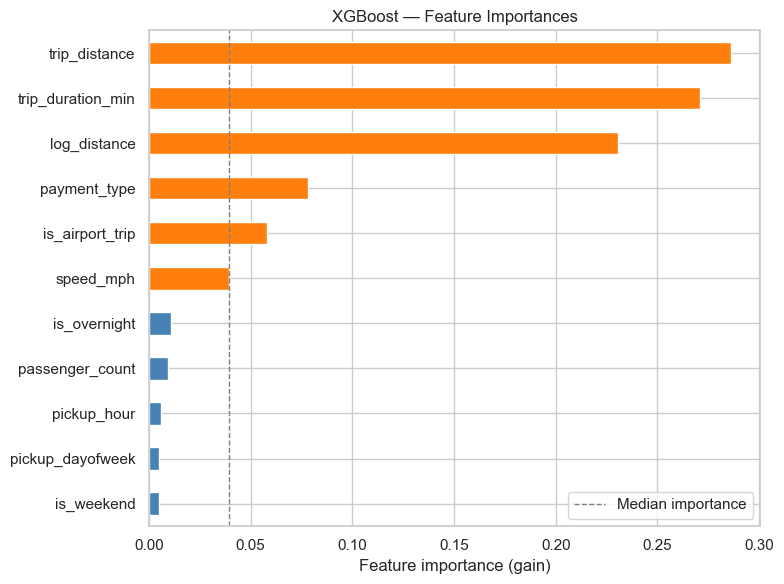

Top 3 features: ['trip_distance', 'trip_duration_min', 'log_distance']

=== H.2 Partial Dependence Plots ===


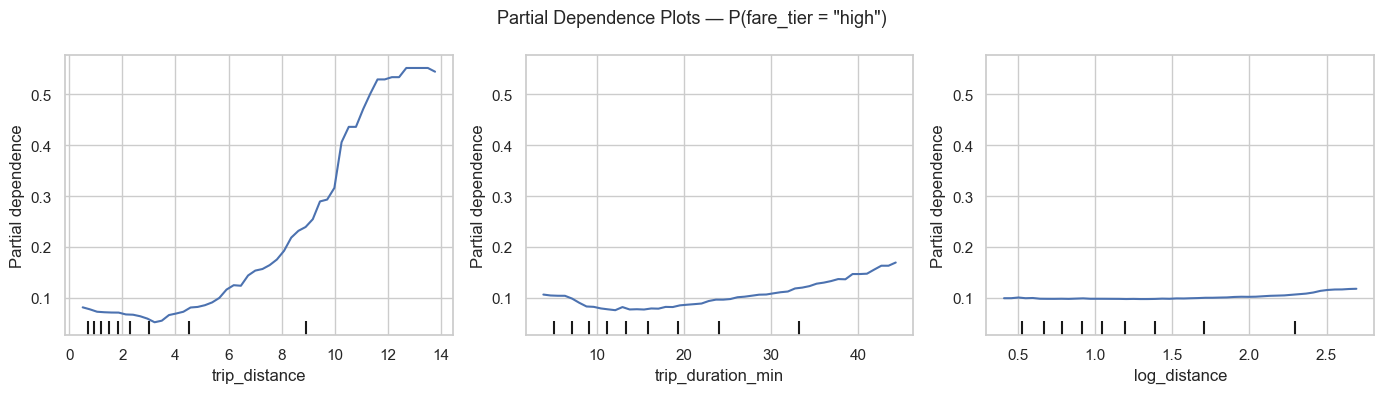

In [24]:
print("=== H.1 Feature Importance ===")
top3_features = plot_feature_importance(best_xgb)

print("\n=== H.2 Partial Dependence Plots ===")
plot_pdp(best_xgb, X_test, ENG_FEATURES, class_names, top3_features)


### Interpretation Discussion

**Feature importance:**  
`trip_distance`, `trip_duration_min`, and `log_distance` dominate — directly extending the Phase 1 finding that fare is strongly tied to trip structure. Together, they show that distance remains the clearest separator across `low`, `mid`, and `high` fare tiers, while duration adds extra signal for trips that are long in both time and distance.  
Among the engineered features, `is_airport_trip` is especially informative, consistent with NYC taxi pricing patterns where airport trips have distinctive fare behaviour. The time-based variables (`pickup_hour`, `pickup_dayofweek`, `is_weekend`, `is_overnight`) contribute smaller but useful signal by capturing when trips are more likely to fall into higher fare tiers.

**PDPs — P(`fare_tier` = `high`):**  
- **`trip_distance`**: Probability of the `high` tier rises sharply with distance and approaches near-certainty for the longest trips.
- **`trip_duration_min`**: Longer trips are also more likely to be classified as `high`, though the effect is weaker than pure distance.
- **`log_distance`**: The transformed feature shows the same underlying pattern more smoothly, confirming that the non-linear distance transform helps the model separate fare tiers.

**Cluster–supervised alignment:**  
The same trip-structure variables that separate `fare_tier` classes (`trip_distance`, `trip_duration_min`, `speed_mph`) are also the variables that naturally divide trips into compact clusters, confirming that the unsupervised structure discovered in Section 11 is genuinely informative and aligned with the supervised task.

<a id="ethical-considerations"></a>
## Ethical Considerations

**Bias:**
A key ethical consideration is the potential for certain features to act as indirect proxies of socioeconomic status. For example, variables such as airport trips or payment type may correlate with income level, which can influence how patterns are learned by the model(s). As a result, the clustering may reflect underlying socioeconomic groupings rather than behavioral patterns. This becomes important when interpreting the results, as what appears to be a meaningful behavioral distinction can in reality be driven by differences in access or financial means, which can lead to misleading conclusions if not considered carefully.

**Privacy:**
Although the TLC dataset does not contain information that can directly identify a person, the combination of precise timestamps and location (`PULocationID` and `DOLocationID`) could be sufficient for re-identification when cross-referenced with auxiliary sources such as ride receipts, flight records, CCTV footage, among others. Even anonymized trip data can reveal highly sensitive personal information, such as regular visits to medical facilities, places of worship, or private residences. Importantly, passengers did not affirmatively consent to their mobility data being used for model taining.

**Limitations:**
The `fare_tier` thresholds (\\$15 and \\$40 respectively) were informed by domain intuition, where fares below \\$15 typically correspond to short trips, fares between \\$15 and \\$40 represent standard urban trips, and fares above $40 capture long-distance or premium trips. However, despite being informed by domain intuition, they are ultimately arbitrary values, nor are the low-mid-high thresholds officially defined by TLC. Different cutoffs would alter class boundaries, imbalance ratios, and feature importance rankings. Furthermore, all taxi trips were treated as independent observations. In the real-world, trips often cluster for a number of reasons: many trips come from the same driver, happened during the same rush hour, and/or started in the same few busy zones. This can lead to overly optimistic performance estimates, as the model may exploit intra-cluster correlations rather than learn generalizable tip characteristics, thereby reducing its robustness when applied to new drivers, time periods, or locations.

**Future Work:**
As it stands, the analysis is limited to just 500k row samples due to computational constraints. By scaling the project with distributed frameworks like Apache Spark, we could train on the full 83 million record dataset, which could reveal deeper patterns and improve the robustness of the unsupervised clustering. Moreover, an interactive visualization dashboard could be developed to allow users to explore clustering results and feature relationships dynamically, making the analysis more intuitive and accessible.

<a id="division-of-labour"></a>

## Division of Labour

| Team Member | Student ID | Primary Contributions |
|---|---|---|
| **Arad Hajari** | 40242069 | Sections 6 & 12 — Baseline linear regression (train/val/test split, metrics), residual analysis, interpretation discussion, XGBoost feature importance and Partial Dependence Plots |
| **Noah Burns** | 40237138 | Sections 3 & 11 — Data cleaning (deduplication, imputation, plausibility filters, audit JSON), unsupervised learning (PCA, KMeans k-selection, stability checks, cluster diagnostics), residual plot, general notebook revision and section merging |
| **Paolo Ciccarelli** | 40286203 | Sections 7, 9 & 10 — Feature Engineering (time features, log-distance transform, domain flags), Advanced Supervised Learning (Random Forest, MLP, XGBoost GridSearchCV, ROC curves, confusion matrices), Feature Selection comparison (Filter / Wrapper / Embedded) |
| **Sang Ho Lee** | 40229178 | Sections 1, 2 & 5 — Project scope definition, data retrieval (Parquet downloads, checksum logging, size verification), exploratory data analysis, EDA interpretation, documentation and README |

## AI Usage Disclosure

GitHub Copilot was used to assist with code structure, docstrings, and wording of markdown narratives. All submitted code and outputs were reviewed, understood, and validated by the team members responsible for each section.


<a id="references"></a>
## References

**Dataset**
1. New York City Taxi and Limousine Commission (TLC). *TLC Trip Record Data*. NYC Open Data. Retrieved January 2024 – December 2025. https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

**Core Libraries**

2.  scikit-learn Documentation: https://scikit-learn.org
3.  pandas Documentation: https://pandas.pydata.org/docs/
4.  Matplotlib Documentation: https://matplotlib.org/
5.  XGBoost Documentation: https://xgboost.readthedocs.io/en/release_3.2.0/